# Spotify Data Analysis -- Benjamin Khothsombath

## Introduction

In this notebook, I outline my analysis of using time-series methods to analyze my Spotify listening trends.

As a reminder, our goal is to answer three questions:

1. Do my listening trends during my undergraduate years exhibit periodicity within either a daily, weekly, or yearly cycle? Can this be used to perform prediction on my listening?
2. Is there are any relationship between my listening trends across my top 5 genres?

First let's setup the environment and load in the data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
import warnings
from scipy import signal
from scipy.stats import norm
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf, ccf, grangercausalitytests
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm
from pmdarima import auto_arima
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import os
warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (12, 4)})

# Set up paths
DATA_DIR = os.path.join("..", "data")
PLOT_DIR = os.path.join("..", "plots")

# Load in Data
overall_time_series = pd.read_csv(os.path.join(DATA_DIR, "overall_time_series.csv"),
                                 index_col='ts',
                                 parse_dates=True)
genre_time_series = pd.read_csv(os.path.join(DATA_DIR, "genre_time_series.csv"),
                                 index_col='ts',
                                 parse_dates=True)

overall_time_series.rename(columns={'0': 'plays'}, inplace=True)

## Exploratory Data Analysis

First, since one of our goals is prediction, let's split the data into training and testing. One thing to consider is if there is seasonality or drift in our data, which we can start by looking for visually.

In [2]:
TRAIN_END = "2021-06-30"
TEST_START = "2021-07-01"
 
train = overall_time_series.loc[:TRAIN_END]
test  = overall_time_series.loc[TEST_START:]
 
print(f"\nTrain: {train.index[0].date()} --> {train.index[-1].date()} ({len(train)} days)")
print(f"Test:  {test.index[0].date()} --> {test.index[-1].date()}  ({len(test)} days)")


Train: 2018-10-08 --> 2021-06-30 (997 days)
Test:  2021-07-01 --> 2022-06-21  (356 days)


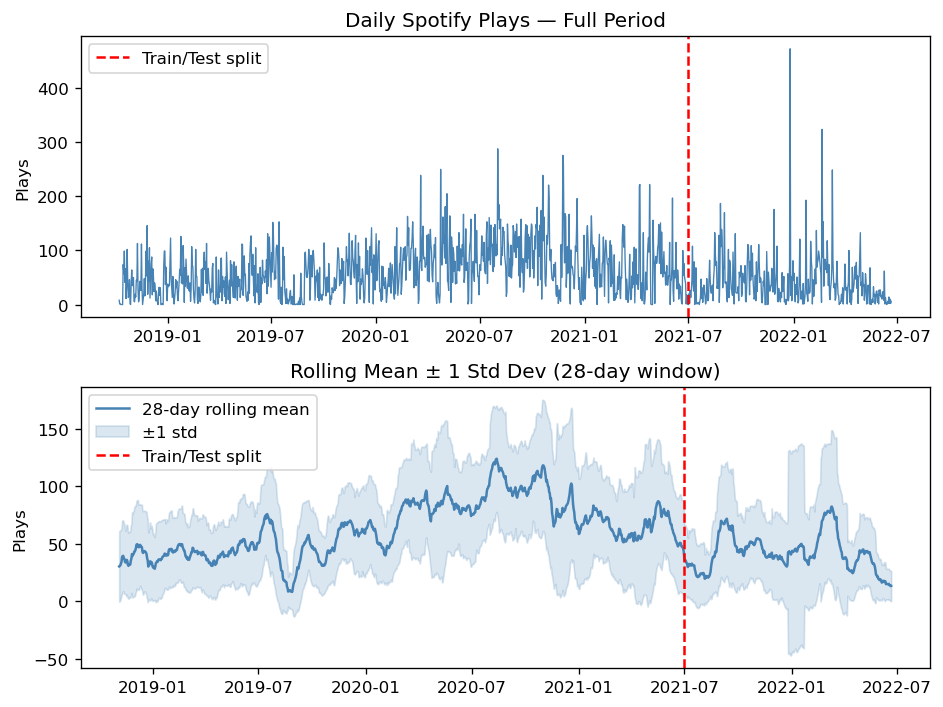

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6))
 
# Plot The Overall Time Series, Separated by Train and Test
axes[0].plot(overall_time_series.index, overall_time_series["plays"], lw=0.8, color="steelblue")
axes[0].axvline(pd.Timestamp(TEST_START), color="red", ls="--", label="Train/Test split")
axes[0].set_title("Daily Spotify Plays — Full Period")
axes[0].set_ylabel("Plays")
axes[0].legend()
 
# Rolling mean and SD over a 28 day window.
rolling_mean = overall_time_series["plays"].rolling(28).mean()
rolling_std  = overall_time_series["plays"].rolling(28).std()
axes[1].plot(overall_time_series.index, rolling_mean, label="28-day rolling mean", color="steelblue")
axes[1].fill_between(
    overall_time_series.index,
    rolling_mean - rolling_std,
    rolling_mean + rolling_std,
    alpha=0.2, color="steelblue", label="±1 std"
)
axes[1].axvline(pd.Timestamp(TEST_START), color="red", ls="--", label="Train/Test split")
axes[1].set_title("Rolling Mean ± 1 Std Dev (28-day window)")
axes[1].set_ylabel("Plays")
axes[1].legend()
 
plt.tight_layout()
plt.savefig("../plots/eda_overview.png", bbox_inches="tight")
plt.show()


Looking at these plots, we notice a few things. First, there is a trend in the data. The average number of plays seems to increase during 2020 and fall back down during 2021. We can attribute this to the pandemic as during this time, I was at home more often. Furthermore, we see that the variance is wider during the pandemic than it was during other years. This is a violation of the ARIMA assumptions, so when we conduct ARIMA, we should perform a log transformation and back-transform to the number of plays. We can perform the ADF and KPSS test at the 5\% significance level to test confirm that the time series is non-stationary.

In [4]:
def stationarity_report(series: pd.Series, name: str = "Series"):
    print(f"\n{'='*50}")
    print(f"Stationarity Tests: {name}")
    print(f"{'='*50}")
 
    # ADF
    adf_result = adfuller(series.dropna(), autolag="AIC")
    print(f"\nADF Test:")
    print(f"Statistic: {adf_result[0]:.4f}")
    print(f"p-value: {adf_result[1]:.4f}")
    print(f"Lags used: {adf_result[2]}")
    for k, v in adf_result[4].items():
        print(f"Critical ({k}): {v:.4f}")
    print("Conclusion:", "REJECT H0 --> likely stationary" if adf_result[1] < 0.05
          else "FAIL TO REJECT H0 --> likely non-stationary")

    # KPSS
    kpss_result = kpss(series.dropna(), regression="c", nlags="auto")
    print(f"\nKPSS Test:")
    print(f"Statistic: {kpss_result[0]:.4f}")
    print(f"p-value: {kpss_result[1]:.4f}")
    for k, v in kpss_result[3].items():
        print(f"  Critical ({k}): {v:.4f}")
    print("Conclusion:", "REJECT H0 --> likely non-stationary" if kpss_result[1] < 0.05
          else "FAIL TO REJECT H0 --> likely stationary")
 
stationarity_report(train["plays"], name="Overall Daily Plays (Train)")
 
# Also test first difference
stationarity_report(train["plays"].diff().dropna(), name="First-Differenced Daily Plays (Train)")


Stationarity Tests: Overall Daily Plays (Train)

ADF Test:
Statistic: -6.8990
p-value: 0.0000
Lags used: 6
Critical (1%): -3.4370
Critical (5%): -2.8645
Critical (10%): -2.5683
Conclusion: REJECT H0 --> likely stationary

KPSS Test:
Statistic: 2.4025
p-value: 0.0100
  Critical (10%): 0.3470
  Critical (5%): 0.4630
  Critical (2.5%): 0.5740
  Critical (1%): 0.7390
Conclusion: REJECT H0 --> likely non-stationary

Stationarity Tests: First-Differenced Daily Plays (Train)

ADF Test:
Statistic: -11.2896
p-value: 0.0000
Lags used: 22
Critical (1%): -3.4371
Critical (5%): -2.8645
Critical (10%): -2.5684
Conclusion: REJECT H0 --> likely stationary

KPSS Test:
Statistic: 0.1538
p-value: 0.1000
  Critical (10%): 0.3470
  Critical (5%): 0.4630
  Critical (2.5%): 0.5740
  Critical (1%): 0.7390
Conclusion: FAIL TO REJECT H0 --> likely stationary


From this, we see that both tests disagree on whether the original training data is stationary, which seems contradictory but has some further implications. In particular, the ADF test is testing for whether there is a unit root, that is, if the time series can be expressed as

$$
x_t = \gamma x_{t-1} + \epsilon_t
$$

it's testing if $\gamma=1$. However, the KPSS is testing for more generalized non-stationarity, so it identifies that even if the unit root is 0, there is still some trend, which we've identified as the pandemic-trend. We can also look at the ACF/PACF plots on the training data. The slow decay in ACF and the lag 7 spike for the PACF suggests some weekly structure.

Furthermore, we see that the tests agree when we first-difference the series, which will motivate $d=1$ in our ARIMA models.

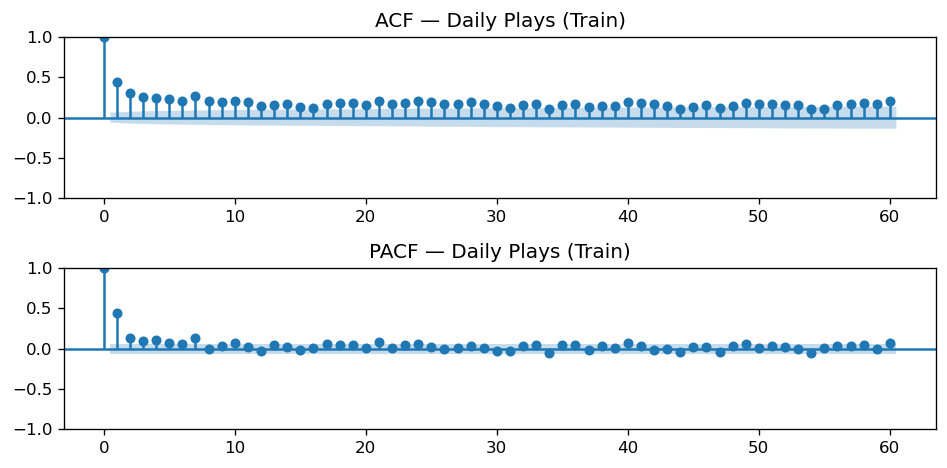

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(8, 4))
plot_acf(train["plays"],  lags=60, ax=axes[0], title="ACF — Daily Plays (Train)")
plot_pacf(train["plays"], lags=60, ax=axes[1], title="PACF — Daily Plays (Train)")
plt.tight_layout()
plt.savefig("../plots/acf_pacf_daily.png", bbox_inches="tight")
plt.show()

Next, we can perform an STL decomposition to separate out the time series into a seasonal component + a trend component. We'll start with a period of 7 since we identify a slight weekly trend.

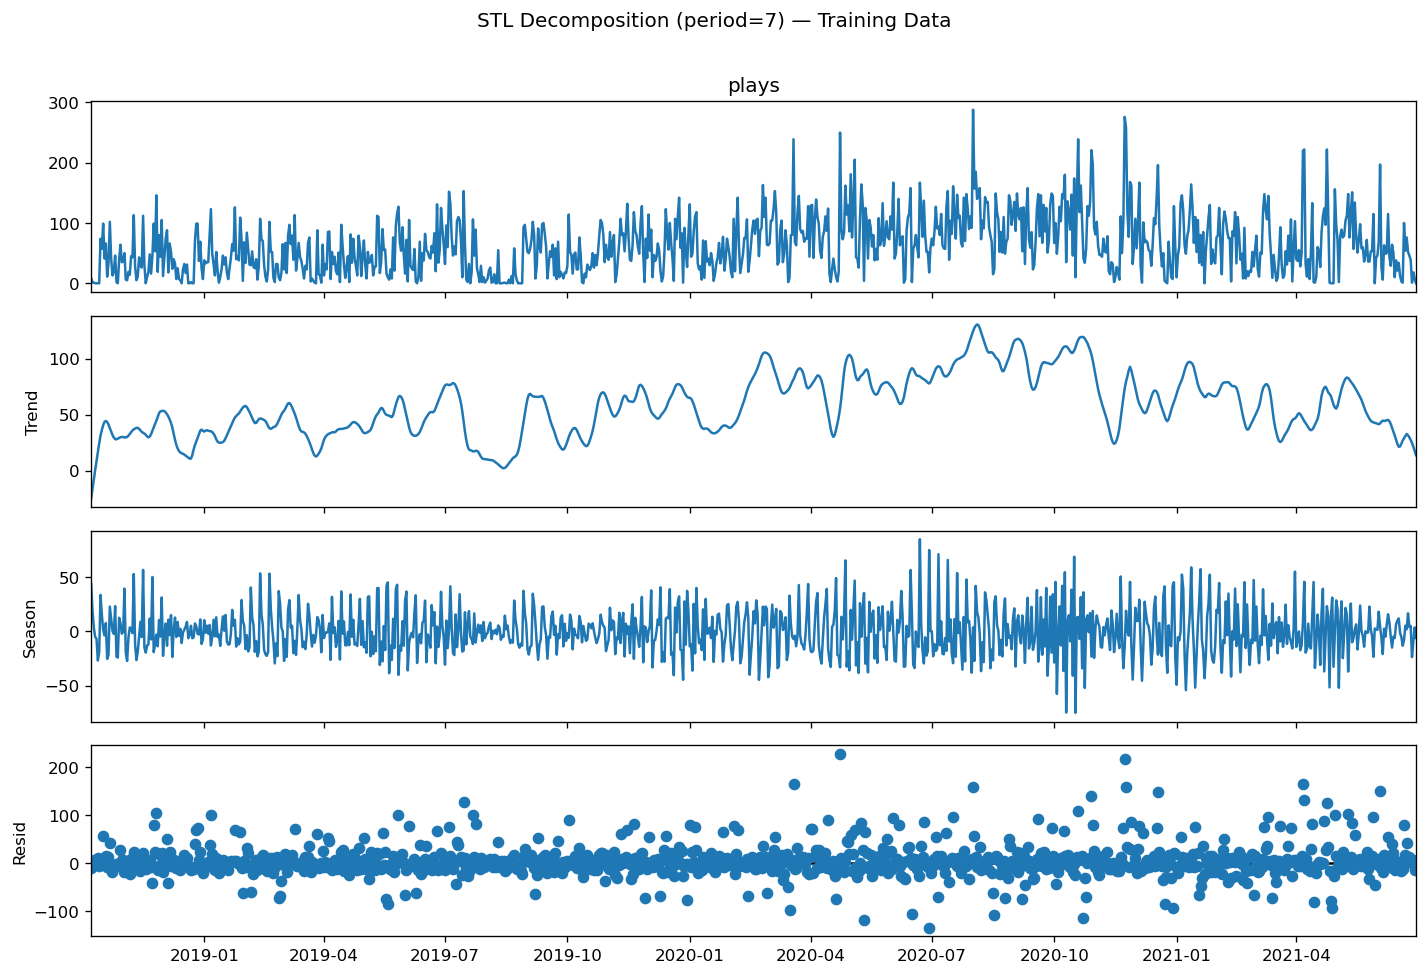

In [6]:
stl = STL(train["plays"], period=7, robust=True).fit()
fig = stl.plot()
fig.set_size_inches(12, 8)
plt.suptitle("STL Decomposition (period=7) — Training Data", y=1.01)
plt.tight_layout()
plt.savefig("../plots/stl_decomp_7.png", bbox_inches="tight")
plt.show()

From the above plots, we see that indeed, there seems to be some trend during the pandemic era, as the plays get higher before coming back down near the end of the pandemic. We can make the trend more clear by looking at the STL decomposition with a 28 day period. I choose 28 here as a middle-ground between a weekly period and a yearly period. A 365-day window is not enough to accurately measure trend.

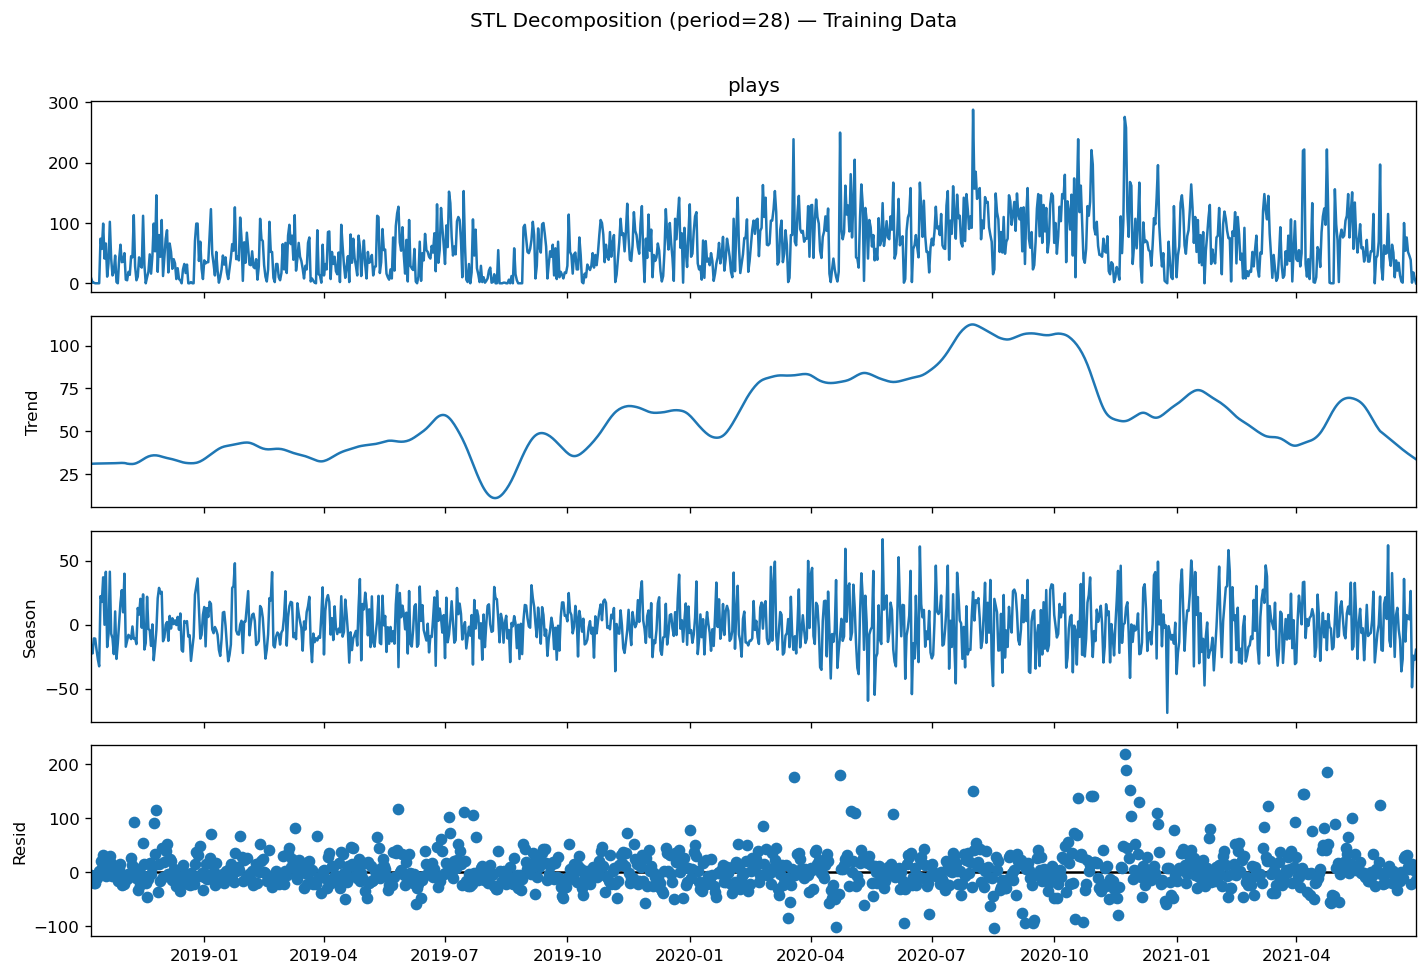

In [7]:
stl_28 = STL(train["plays"], period=28, robust=True).fit()
fig = stl_28.plot()
fig.set_size_inches(12, 8)
plt.suptitle("STL Decomposition (period=28) — Training Data", y=1.01)
plt.tight_layout()
plt.savefig("../plots/stl_decomp_28.png", bbox_inches="tight")
plt.show()

From here, the trend during the pandemic era more clearly jump out. To identify periodicity, we can also look at the number of plays by day/week.

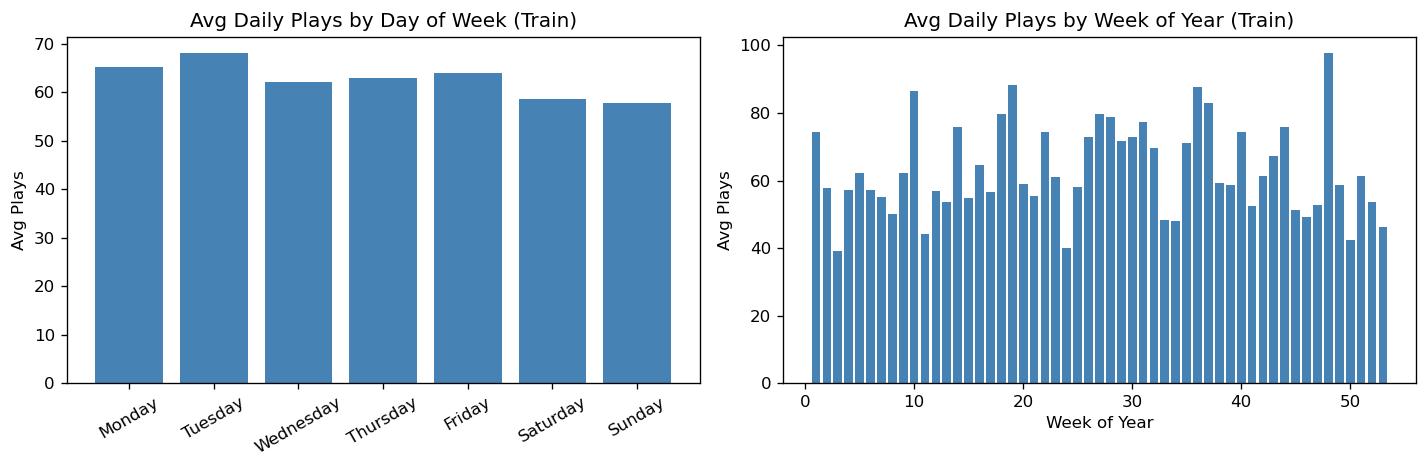

In [8]:
# Day-of-week average plays
dow_avg = train.copy()
dow_avg["day_of_week"] = train.index.day_name()
DOW_ORDER = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow_means = dow_avg.groupby("day_of_week")["plays"].mean().reindex(DOW_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(DOW_ORDER, dow_means.values, color="steelblue")
axes[0].set_title("Avg Daily Plays by Day of Week (Train)")
axes[0].set_ylabel("Avg Plays")
axes[0].tick_params(axis='x', rotation=30)

# Week-of-year seasonality
dow_avg["week_of_year"] = train.index.isocalendar().week.astype(int)
woy_means = dow_avg.groupby("week_of_year")["plays"].mean()
axes[1].bar(woy_means.index, woy_means.values, color="steelblue", width=0.8)
axes[1].set_title("Avg Daily Plays by Week of Year (Train)")
axes[1].set_xlabel("Week of Year")
axes[1].set_ylabel("Avg Plays")

plt.tight_layout()
plt.show()

From this, we see that my listening is rather consistent day-over-day, so while we observed a very slight lag-7 jump in the PACF plot, these plots confirm that it's a rather weak effect. Over time, we also see that there my listening history varies week-by-week, though it's difficult to determine if there's a clear weekly pattern.

For now, let's perform a log transform on the training data and see if this resolves heteroskedasticity. If so, we can work with the data on the log-scale to satisfy some of the model assumptions.

In [9]:
train_log = np.log1p(train["plays"])
test_log  = np.log1p(test["plays"])

# Re-run stationarity on log-transformed series
stationarity_report(train_log, name="log(1 + plays) — Train")
stationarity_report(train_log.diff().dropna(), name="First-Diff log(1+plays) — Train")


Stationarity Tests: log(1 + plays) — Train

ADF Test:
Statistic: -7.3423
p-value: 0.0000
Lags used: 6
Critical (1%): -3.4370
Critical (5%): -2.8645
Critical (10%): -2.5683
Conclusion: REJECT H0 --> likely stationary

KPSS Test:
Statistic: 1.6973
p-value: 0.0100
  Critical (10%): 0.3470
  Critical (5%): 0.4630
  Critical (2.5%): 0.5740
  Critical (1%): 0.7390
Conclusion: REJECT H0 --> likely non-stationary

Stationarity Tests: First-Diff log(1+plays) — Train

ADF Test:
Statistic: -10.6232
p-value: 0.0000
Lags used: 20
Critical (1%): -3.4371
Critical (5%): -2.8645
Critical (10%): -2.5684
Conclusion: REJECT H0 --> likely stationary

KPSS Test:
Statistic: 0.1224
p-value: 0.1000
  Critical (10%): 0.3470
  Critical (5%): 0.4630
  Critical (2.5%): 0.5740
  Critical (1%): 0.7390
Conclusion: FAIL TO REJECT H0 --> likely stationary


From here, we see that the results fo the tests do not change. However, the KPSS statistic dropped from 2.4 down to 1.7 after log-transforming, which is an improvement that likely demonstrates that indeed, the log transform did stabilize the variance, even if the series is still likely non-stationary. We can also plot these series to visualize this.

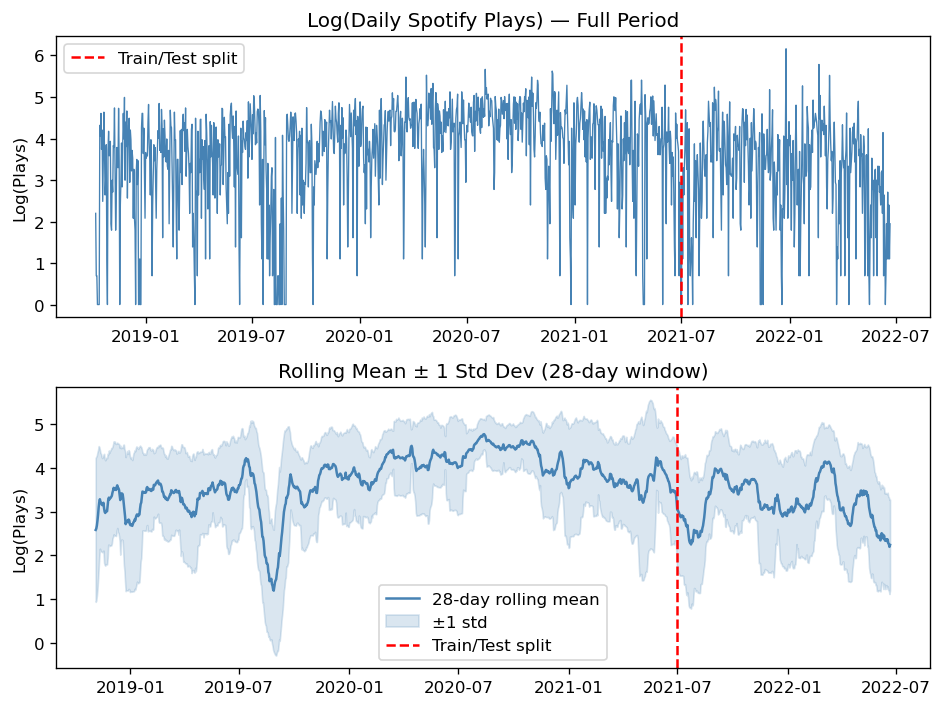

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6))
 
# Plot The Logged Time Series, Separated by Train and Test
axes[0].plot(overall_time_series.index, np.log1p(overall_time_series["plays"]), lw=0.8, color="steelblue")
axes[0].axvline(pd.Timestamp(TEST_START), color="red", ls="--", label="Train/Test split")
axes[0].set_title("Log(Daily Spotify Plays) — Full Period")
axes[0].set_ylabel("Log(Plays)")
axes[0].legend()
 
# Rolling mean and SD over a 28 day window.
rolling_mean = np.log1p(overall_time_series["plays"]).rolling(28).mean()
rolling_std  = np.log1p(overall_time_series["plays"]).rolling(28).std()
axes[1].plot(overall_time_series.index, rolling_mean, label="28-day rolling mean", color="steelblue")
axes[1].fill_between(
    overall_time_series.index,
    rolling_mean - rolling_std,
    rolling_mean + rolling_std,
    alpha=0.2, color="steelblue", label="±1 std"
)
axes[1].axvline(pd.Timestamp(TEST_START), color="red", ls="--", label="Train/Test split")
axes[1].set_title("Rolling Mean ± 1 Std Dev (28-day window)")
axes[1].set_ylabel("Log(Plays)")
axes[1].legend()
 
plt.tight_layout()
#plt.savefig("../plots/log_eda_overview.png", bbox_inches="tight")
plt.show()


On the log scale, the rolling SD is overall more consistent across the full period wider variation during the pandemic, but this looks to have stabilized more, suggesting that the log-transform partially stabilized the variance. The residual heteroskedasticity that we see for some periods is attributable to the mean shift rather than variance inflation.

## Power Spectral Analysis

Let's now begin our spectral analysis. To start, let's take a look at the periodogram of the log-transformed training data. The periodogram assumes stationarity, so let's look at the differenced series on the log scale.

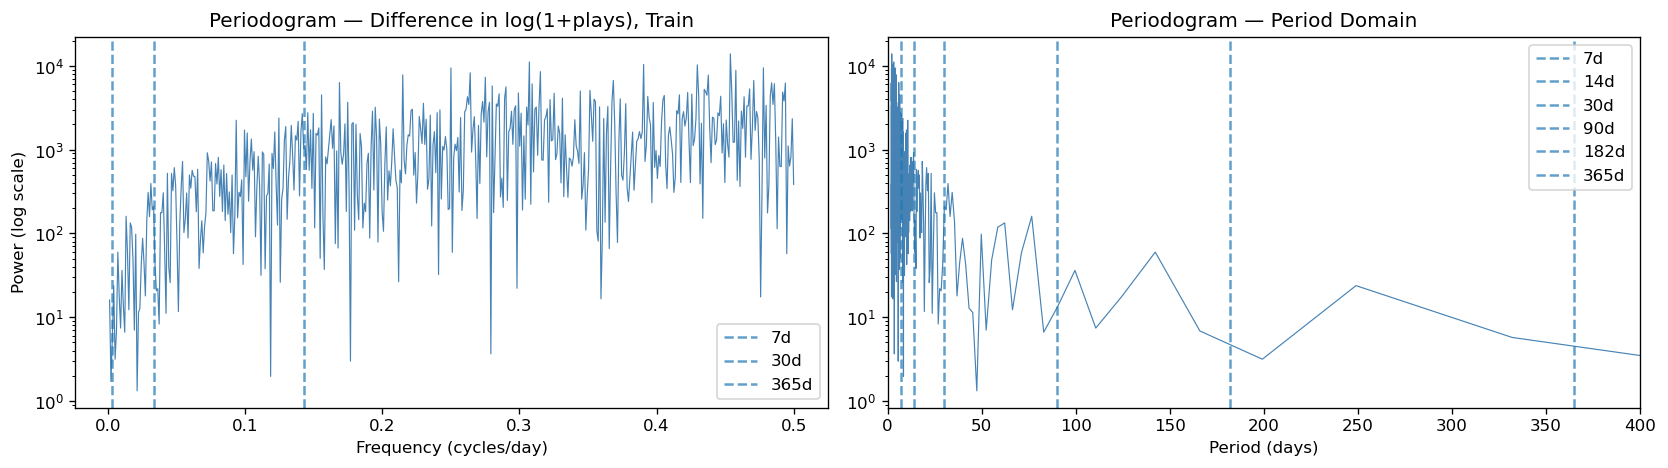

Top 10 dominant periods (days):
period = 2.2 days (freq = 0.45382)
period = 3.3 days (freq = 0.30723)
period = 2.6 days (freq = 0.39056)
period = 2.3 days (freq = 0.42972)
period = 2.1 days (freq = 0.47791)
period = 4.0 days (freq = 0.25000)
period = 2.2 days (freq = 0.45783)
period = 3.2 days (freq = 0.31526)
period = 3.8 days (freq = 0.26406)
period = 4.7 days (freq = 0.21486)


In [11]:
plays_for_periodogram = train_log.diff().dropna().values

freqs = np.fft.rfftfreq(len(plays_for_periodogram), d=1.0)
psd = np.abs(np.fft.rfft(plays_for_periodogram - plays_for_periodogram.mean()))**2

# Only positive frequencies
pos = freqs > 0
freqs, psd = freqs[pos], psd[pos]
periods = 1.0 / freqs

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].semilogy(freqs, psd, lw=0.7, color="steelblue")
for p, label in [(7, "7d"), (30, "30d"), (365, "365d")]:
    axes[0].axvline(1/p, ls="--", alpha=0.7, label=label)
axes[0].set_xlabel("Frequency (cycles/day)")
axes[0].set_ylabel("Power (log scale)")
axes[0].set_title("Periodogram — Difference in log(1+plays), Train")
axes[0].legend()

axes[1].semilogy(periods, psd, lw=0.7, color="steelblue")
# Weekly, Bi-weekly, monthly, tri-monthly, semi-yearly, yearly
for p in [7, 14, 30, 90, 182, 365]:
    axes[1].axvline(p, ls="--", alpha=0.7, label=f"{p}d")
axes[1].set_xlim(0, 400)
axes[1].set_xlabel("Period (days)")
axes[1].set_title("Periodogram — Period Domain")
axes[1].legend()

plt.tight_layout()
plt.show()

# Top-10 dominant periods
top10 = np.argsort(psd)[-10:][::-1]
print("Top 10 dominant periods (days):")
for idx in top10:
    print(f"period = {periods[idx]:.1f} days (freq = {freqs[idx]:.5f})")

From this, we see that the dominant periods are between 2-5 days, but notably, we see no strong peak at a 7-day period, which is consistent with the weak weekly pattern that we observed previously. The dominant periods are 2.2 days, 3.3 days, and 2.6 days, which suggests a lack of a strong deterministic periodicity. Note that these dominant periods are close to the Nyquist limit. Since measurements are taken every day, the Nyquist limit is 0.5, and it's likely that many of these are just high-frequency noisy signals rather than any real periodicity.

With this in mind, let's continue with our sinusoidal regression and see how it performs.


Best Ridge alpha via 5-fold TimeSeriesCV: 142.5103


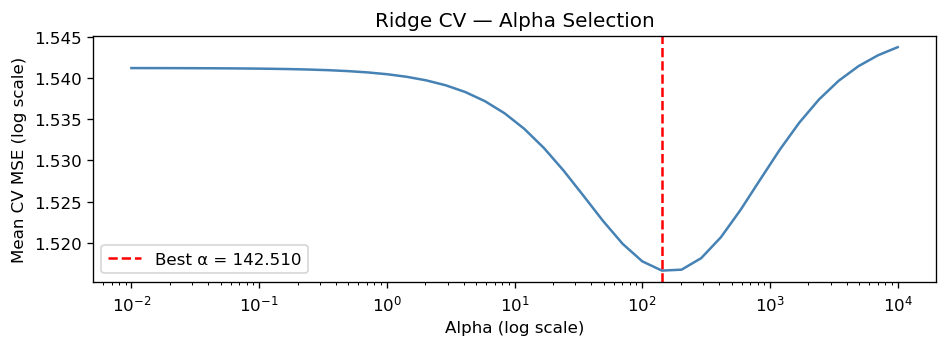

In [12]:
# Select top K peaks by power
K = 10
top_k_idx  = np.argsort(psd)[-K:][::-1]
top_k_freq = freqs[top_k_idx]
 
def build_sinusoid_features(n: int, freqs: np.ndarray, start: int = 0) -> np.ndarray:
    """
    Build design matrix of sin and cos terms for each frequency.
    `start` offsets the time index, used to continue into the test period.
    Returns array of shape (n, 2 * len(freqs)).
    """
    t = np.arange(start, start + n)
    cols = []
    for f in freqs:
        cols.append(np.sin(2 * np.pi * f * t))
        cols.append(np.cos(2 * np.pi * f * t))
    return np.column_stack(cols)

n_train = len(train_log)
n_test = len(test_log)

X_train = build_sinusoid_features(n_train, top_k_freq, start=0)
X_test = build_sinusoid_features(n_test, top_k_freq, start=n_train)

y_train_log = train_log.values
y_test_log = test_log.values
y_test_raw = test["plays"].values  # for back-transformed evaluation

# Fit OLS Sinusoidal regression
ols = LinearRegression(fit_intercept=True)
ols.fit(X_train, y_train_log)

ols_pred_log = ols.predict(X_test)
ols_pred_raw = np.expm1(ols_pred_log)  # back-transform to play counts

# Fit Ridge Sinusoidal Regression with alpha selected via TimeSeriesSplit CV
tscv = TimeSeriesSplit(n_splits=5)
alphas = np.logspace(-2, 4, 40)

cv_rmses = []
for alpha in alphas:
    ridge = Ridge(alpha=alpha, fit_intercept=True)
    fold_mses = []
    for tr_idx, val_idx in tscv.split(X_train):
        ridge.fit(X_train[tr_idx], y_train_log[tr_idx])
        val_pred = ridge.predict(X_train[val_idx])
        fold_mses.append(mean_squared_error(y_train_log[val_idx], val_pred))
    cv_rmses.append(np.mean(fold_mses))

best_alpha = alphas[np.argmin(cv_rmses)]
print(f"\nBest Ridge alpha via 5-fold TimeSeriesCV: {best_alpha:.4f}")

# Plot CV curve
plt.figure(figsize=(8, 3))
plt.semilogx(alphas, cv_rmses, color="steelblue")
plt.axvline(best_alpha, ls="--", color="red", label=f"Best α = {best_alpha:.3f}")
plt.xlabel("Alpha (log scale)")
plt.ylabel("Mean CV MSE (log scale)")
plt.title("Ridge CV — Alpha Selection")
plt.legend()
plt.tight_layout()
plt.show()

ridge_final = Ridge(alpha=best_alpha, fit_intercept=True)
ridge_final.fit(X_train, y_train_log)

ridge_pred_log = ridge_final.predict(X_test)
ridge_pred_raw = np.expm1(ridge_pred_log)

In [13]:
# Get the Mean prediction as a baseline
mean_pred_raw = np.full(n_test, np.expm1(y_train_log.mean()))

def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    print(f"{name:<35s} RMSE = {rmse:6.2f} MAE = {mae:6.2f}")

print("\nTest Set Evaluation (back-transformed to play counts):")
print("-" * 60)
evaluate("Mean Baseline", y_test_raw, mean_pred_raw)
evaluate("OLS Sinusoidal", y_test_raw, ols_pred_raw)
evaluate(f"Ridge (alpha={best_alpha:.3f})", y_test_raw, ridge_pred_raw)


Test Set Evaluation (back-transformed to play counts):
------------------------------------------------------------
Mean Baseline                       RMSE =  46.19 MAE =  29.82
OLS Sinusoidal                      RMSE =  47.35 MAE =  31.00
Ridge (alpha=142.510)               RMSE =  46.89 MAE =  30.46


From this, we see something very interesting. As we previously noted, these high frequency signals are likely overfitting to noise, which we see reflected in our results. A simple mean prediction performs better than both of our models, meaning that the sinusoidal regression is not the model we want to use for prediction. It was a good idea when I initially proposed the project, since I really did expect to see periodicity, but alas, this is more evidence toward there not being periodicity.

Let's look at how sensitive the regressions are to our choice of $K$.

In [14]:
print("\nSensitivity to number of frequencies K (Ridge, test RMSE):")
print("-" * 45)
for k in [3, 5, 7, 10, 15, 20, 100]:
    top_idx_k = np.argsort(psd)[-k:][::-1]
    top_freq_k = np.sort(freqs[top_idx_k])
    Xtr_k = build_sinusoid_features(n_train, top_freq_k, start=0)
    Xte_k = build_sinusoid_features(n_test,  top_freq_k, start=n_train)
    # Re-tune alpha for each K
    cv_k = []
    for alpha in alphas:
        ridge_k = Ridge(alpha=alpha, fit_intercept=True)
        fold_mses_k = []
        for tr_idx, val_idx in tscv.split(Xtr_k):
            ridge_k.fit(Xtr_k[tr_idx], y_train_log[tr_idx])
            fold_mses_k.append(
                mean_squared_error(y_train_log[val_idx], ridge_k.predict(Xtr_k[val_idx]))
            )
        cv_k.append(np.mean(fold_mses_k))
    best_a_k = alphas[np.argmin(cv_k)]
    ridge_k_final = Ridge(alpha=best_a_k, fit_intercept=True).fit(Xtr_k, y_train_log)
    preds_k = np.expm1(ridge_k_final.predict(Xte_k))
    rmse_k  = np.sqrt(mean_squared_error(y_test_raw, preds_k))
    print(f"  K={k:>2d}  best alpha={best_a_k:.3f}  test RMSE={rmse_k:.2f}")



Sensitivity to number of frequencies K (Ridge, test RMSE):
---------------------------------------------
  K= 3  best alpha=142.510  test RMSE=46.77
  K= 5  best alpha=203.092  test RMSE=46.69
  K= 7  best alpha=100.000  test RMSE=46.49
  K=10  best alpha=142.510  test RMSE=46.89
  K=15  best alpha=142.510  test RMSE=47.34
  K=20  best alpha=142.510  test RMSE=47.21
  K=100  best alpha=142.510  test RMSE=52.54


From this, we see that increasing $K$ doesn't help much, again because of the lack of periodicity. In fact, using more frequencies overfits even more, suggesting that there is no particular subset of frequencies that can capture a periodic signal.

Let's plot the forecasted vs actuals and see what that looks like.

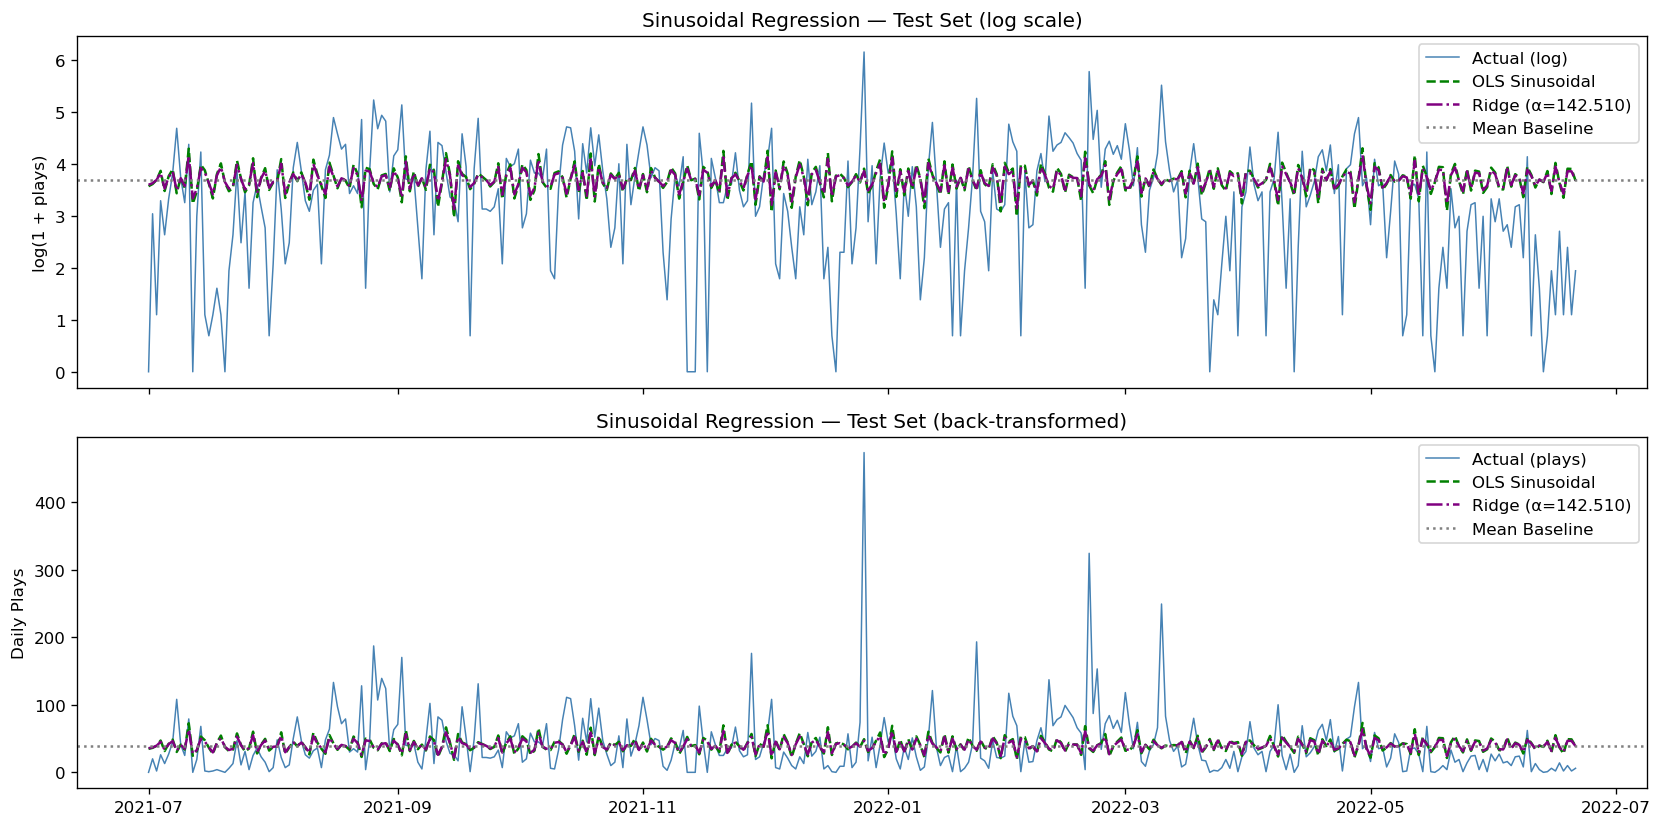

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Log scale
axes[0].plot(test.index, y_test_log, label="Actual (log)", lw=0.9, color="steelblue")
axes[0].plot(test.index, ols_pred_log, label="OLS Sinusoidal", ls="--", color="green")
axes[0].plot(test.index, ridge_pred_log, label=f"Ridge (α={best_alpha:.3f})", ls="-.", color="purple")
axes[0].axhline(y_train_log.mean(), label="Mean Baseline", ls=":", color="grey")
axes[0].set_title("Sinusoidal Regression — Test Set (log scale)")
axes[0].set_ylabel("log(1 + plays)")
axes[0].legend()

# Back-transformed (play counts)
axes[1].plot(test.index, y_test_raw, label="Actual (plays)", lw=0.9, color="steelblue")
axes[1].plot(test.index, ols_pred_raw, label="OLS Sinusoidal", ls="--", color="green")
axes[1].plot(test.index, ridge_pred_raw, label=f"Ridge (α={best_alpha:.3f})", ls="-.", color="purple")
axes[1].axhline(mean_pred_raw[0], label="Mean Baseline", ls=":",  color="grey")
axes[1].set_title("Sinusoidal Regression — Test Set (back-transformed)")
axes[1].set_ylabel("Daily Plays")
axes[1].legend()

plt.tight_layout()
plt.savefig("../plots/sinusoidal_forecast.png", bbox_inches="tight")
plt.show()

From this, we see that there's just a lot of variability in the data that we're not capturing. The regressions that we run are low in amplitude because they minimize overall mean square error, but they simply don't capture the variability.

## SARIMA Modeling

In my project proposal, my plan was to "extend the ARIMA model to that of the Seasonal ARIMA (SARIMA) model because ... it's likely that there exists some seasonality in my listening history." As we go through this analysis, we're seeing that that assumption is looking less likely to be true, but let's gather more evidence to show the lack of periodicity.

We'll use the log-transformed daily plays with $d=1$ for first-differencing, as motivated by our stationarity tests. We'll compare a standard ARIMA model (seasonal ARIMA with $m=1$) against that of a weekly seasonal SARIMA $(m=7)$, which is motivated by our PACF plot that shows weak weekly seasonality. As our test metrics, we'll use RMSE and MAE as before to compare to the previous models, but here we'll use AIC for model selection, which will select the number of autoregressive lags $(p)$ and the number of moving average terms $(q)$ in $(p,d,q)$.

In [16]:
# ARIMA
print("Fitting non-seasonal ARIMA (m=1)...")
arima_nonseasonal = auto_arima(
    train_log,
    d=1,
    seasonal=False,
    max_p=3, max_q=3,
    stepwise=True,
    information_criterion="aic",
    trace=True,
    error_action="ignore",
    suppress_warnings=True,
)

print(f"\nBest non-seasonal order: {arima_nonseasonal.order}")
print(f"AIC: {arima_nonseasonal.aic():.2f}")

# SARIMA
print("\n" + "="*50)
print("Fitting seasonal SARIMA (m=7)...")
arima_seasonal = auto_arima(
    train_log,
    d=1,
    seasonal=True,
    m=7,
    max_p=3, max_q=3,
    max_P=2, max_Q=2,
    D=None, # let auto_arima choose seasonal differencing
    stepwise=True,
    information_criterion="aic",
    trace=True,
    error_action="ignore",
    suppress_warnings=True,
)
print(f"\nBest seasonal order: {arima_seasonal.order} x {arima_seasonal.seasonal_order}")
print(f"AIC: {arima_seasonal.aic():.2f}")

# Report which wins
print("\n--- AIC Comparison ---")
print(f"Non-seasonal ARIMA{arima_nonseasonal.order}: AIC = {arima_nonseasonal.aic():.2f}")
print(f"Seasonal SARIMA{arima_seasonal.order}x{arima_seasonal.seasonal_order}: AIC = {arima_seasonal.aic():.2f}")
best_model_label = "Non-seasonal" if arima_nonseasonal.aic() < arima_seasonal.aic() else "Seasonal"
print(f"Winner: {best_model_label}")

Fitting non-seasonal ARIMA (m=1)...
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=2898.984, Time=0.55 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=3240.022, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=3099.771, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=2958.775, Time=0.06 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=3238.026, Time=0.01 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=2902.127, Time=0.32 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=2903.823, Time=0.24 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=2907.820, Time=0.31 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=2904.725, Time=0.67 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=2905.946, Time=0.15 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=2900.744, Time=0.57 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=2904.517, Time=0.34 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=2904.764, Time=0.77 sec
 ARIMA(2,1,2)(0,0,0)[0]             : AIC=2896.851, Time=0.28 s

Our model selection shows that a $(1,1,2)$ ARIMA was our best non-seasonal ARIMA and that the SARIMA has the same set of non-seasonal parameters, and has $(1,0,0,7)$ as the best selection of seasonal parameters, where $P=1$ is the seasonal AR order, $D=0$ is the seasonal differencing, $Q=0$ is the seasonal MA order, and $s=7$ was fixed as the weekly period. The AIC of the seasonal ARIMA is only slightly lower by 10, which suggests that there is slight improvement in fit by including the seasonality component, but not much.

Now, let's fit each winning model and observe the residuals.

                                     SARIMAX Results                                      
Dep. Variable:                              plays   No. Observations:                  997
Model:             SARIMAX(1, 1, 2)x(1, 0, [], 7)   Log Likelihood               -1417.750
Date:                            Wed, 13 May 2026   AIC                           2845.500
Time:                                    23:03:08   BIC                           2869.978
Sample:                                10-08-2018   HQIC                          2854.809
                                     - 06-30-2021                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6033      0.058     10.428      0.000       0.490       0.717
ma.L1         -1.2531      0.070   

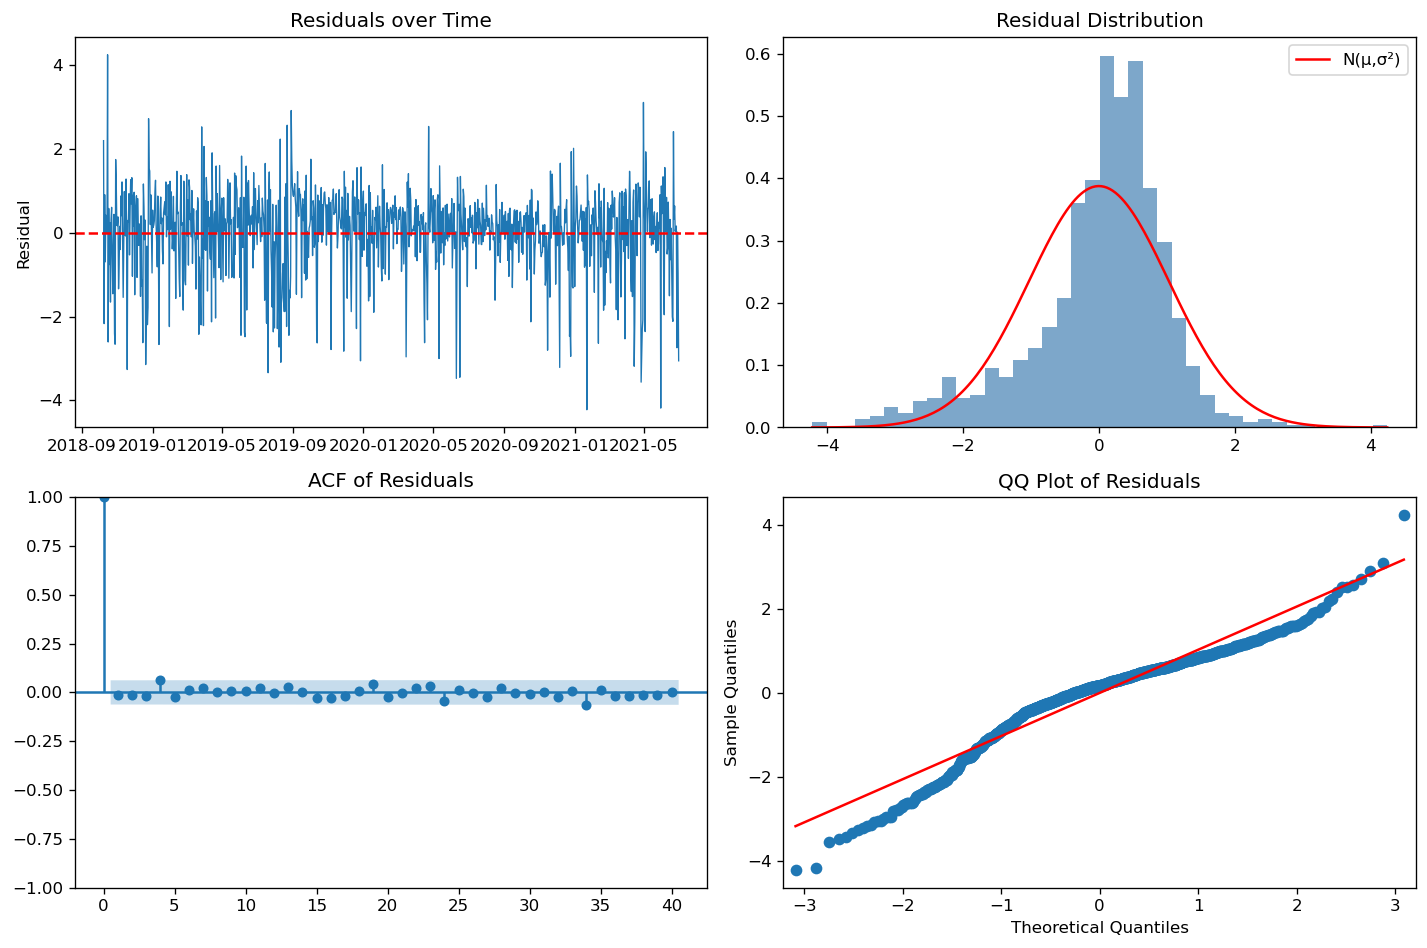


Ljung-Box Test on Residuals:
      lb_stat  lb_pvalue
7    5.755321   0.568592
14   7.168637   0.928015
21  11.919473   0.941766
28  16.886072   0.950805


In [17]:
winning_order = arima_seasonal.order
winning_seasonal = arima_seasonal.seasonal_order

sarima_fit = SARIMAX(
    train_log,
    order=winning_order,
    seasonal_order=winning_seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)

print(sarima_fit.summary())

# Residual Plots

residuals = sarima_fit.resid.dropna()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Residuals over time
axes[0,0].plot(train_log.index[len(train_log)-len(residuals):], residuals, lw=0.8)
axes[0,0].axhline(0, ls="--", color="red")
axes[0,0].set_title("Residuals over Time")
axes[0,0].set_ylabel("Residual")

# Histogram with normal overlay
axes[0,1].hist(residuals, bins=40, density=True, color="steelblue", alpha=0.7)
xr = np.linspace(residuals.min(), residuals.max(), 200)
axes[0,1].plot(xr, norm.pdf(xr, residuals.mean(), residuals.std()), "r-", label="N(μ,σ²)")
axes[0,1].set_title("Residual Distribution")
axes[0,1].legend()

# ACF of residuals
plot_acf(residuals, lags=40, ax=axes[1,0], title="ACF of Residuals")

# QQ plot
sm.qqplot(residuals, line="s", ax=axes[1,1])
axes[1,1].set_title("QQ Plot of Residuals")

plt.tight_layout()
plt.savefig("../plots/sarima_diagnostics.png", bbox_inches="tight")
plt.show()

# Ljung-Box test
lb = acorr_ljungbox(residuals, lags=[7, 14, 21, 28], return_df=True)
print("\nLjung-Box Test on Residuals:")
print(lb)

From this, we see that all components of our SARIMA model are statisticlly significant at the 5\% level, with the residuals looking to be random, but not quite normally distributed. This means that inference on the components will not be robust, but we can still perform prediction. Furthermore, we are going to back transform to the original units of songs played, so the confidence interval will not quite be correct, but we can still use it as a rough heuristic with a graint of salt. We also see that the ACF for lags after 0 are very small, meaning that the degree of differencing was appropriate.

We also perform the Ljung-Box Test on residuals. The p-values being $>>0.05$ for lags of 7, 14, 21, and 28 indicate that our model is not missing any components.

Let's now see how this model performs in comparison to the other models.

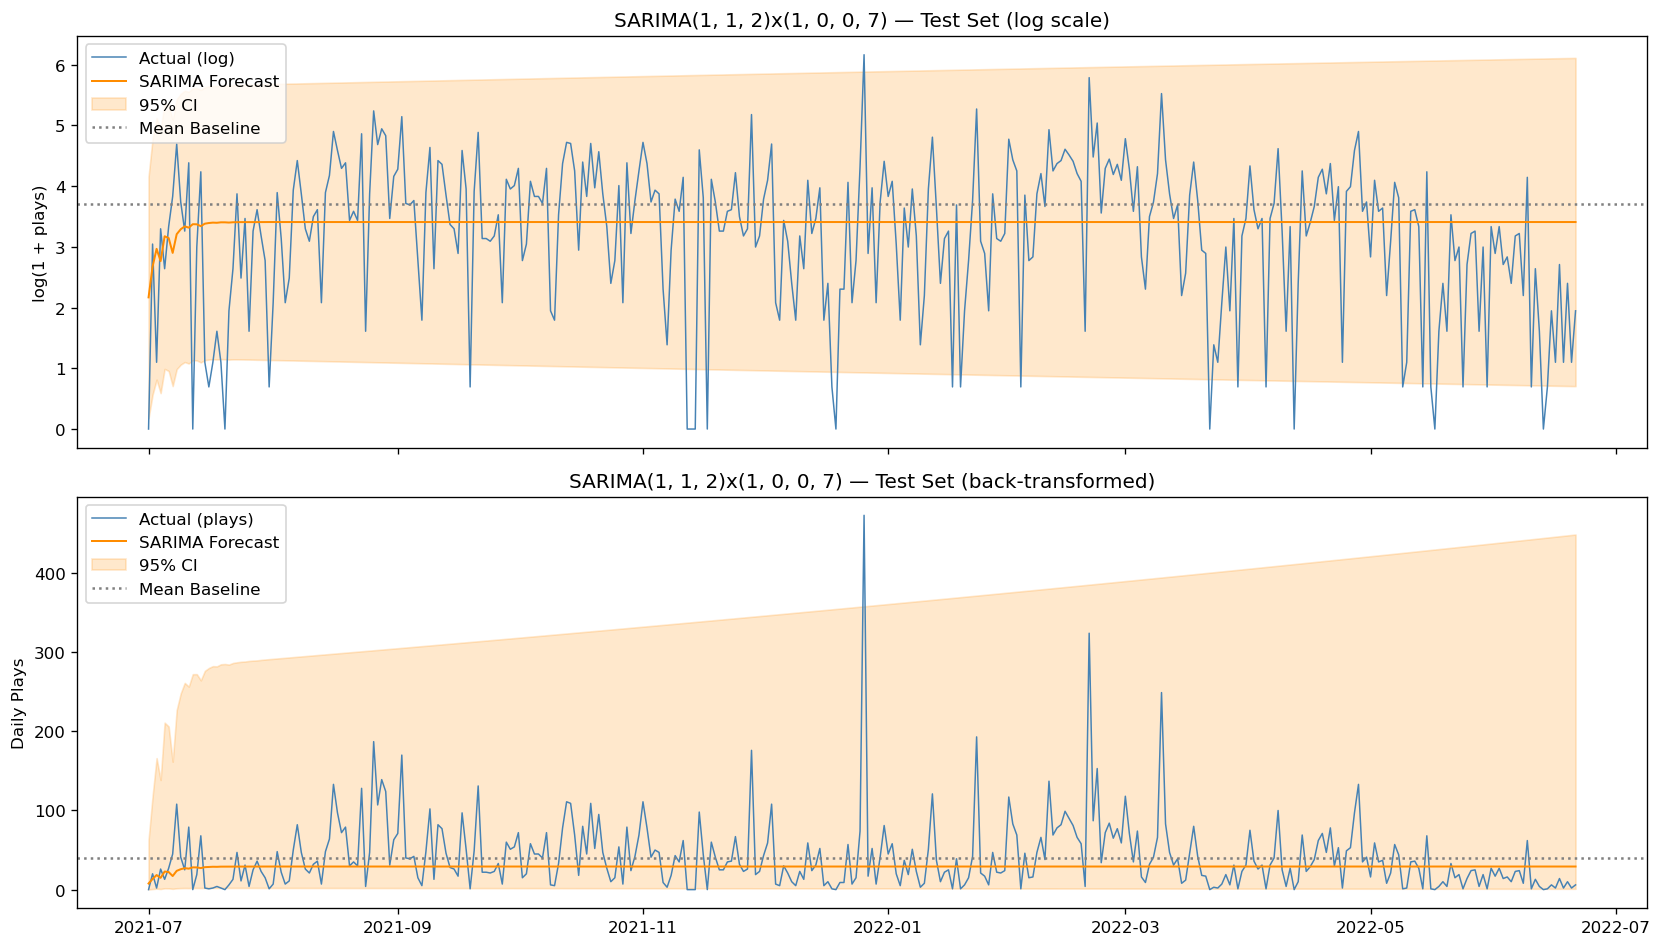


--- Test Set Evaluation ---
------------------------------------------------------------
Mean Baseline                       RMSE =  46.19 MAE =  29.82
OLS Sinusoidal                      RMSE =  47.35 MAE =  31.00
Ridge (alpha=142.510)               RMSE =  46.89 MAE =  30.46
SARIMA(1, 1, 2)x(1, 0, 0, 7)        RMSE =  47.76 MAE =  28.90


In [18]:
forecast_result = sarima_fit.get_forecast(steps=len(test))
pred_log = forecast_result.predicted_mean
conf_int_log = forecast_result.conf_int(alpha=0.05)

# Back-transform
pred_raw     = np.expm1(pred_log)
ci_lower_raw = np.expm1(conf_int_log.iloc[:, 0])
ci_upper_raw = np.expm1(conf_int_log.iloc[:, 1])

# Plot — log scale and back-transformed
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(test.index, y_test_log,  label="Actual (log)",        lw=0.9, color="steelblue")
axes[0].plot(test.index, pred_log,    label="SARIMA Forecast",     lw=1.2, color="darkorange")
axes[0].fill_between(test.index,
                     conf_int_log.iloc[:,0], conf_int_log.iloc[:,1],
                     alpha=0.2, color="darkorange", label="95% CI")
axes[0].axhline(y_train_log.mean(), ls=":", color="grey", label="Mean Baseline")
axes[0].set_title(f"SARIMA{winning_order}x{winning_seasonal} — Test Set (log scale)")
axes[0].set_ylabel("log(1 + plays)")
axes[0].legend()

axes[1].plot(test.index, y_test_raw, label="Actual (plays)", lw=0.9, color="steelblue")
axes[1].plot(test.index, pred_raw, label="SARIMA Forecast", lw=1.2, color="darkorange")
axes[1].fill_between(test.index, ci_lower_raw, ci_upper_raw,
                     alpha=0.2, color="darkorange", label="95% CI")
axes[1].axhline(mean_pred_raw[0], ls=":", color="grey", label="Mean Baseline")
axes[1].set_title(f"SARIMA{winning_order}x{winning_seasonal} — Test Set (back-transformed)")
axes[1].set_ylabel("Daily Plays")
axes[1].legend()

plt.tight_layout()
plt.savefig("../plots/sarima_forecast.png", bbox_inches="tight")
plt.show()

# Evaluate
print("\n--- Test Set Evaluation ---")
print("-" * 60)
evaluate("Mean Baseline", y_test_raw, mean_pred_raw)
evaluate("OLS Sinusoidal", y_test_raw, ols_pred_raw)
evaluate(f"Ridge (alpha={best_alpha:.3f})", y_test_raw, ridge_pred_raw)
evaluate(f"SARIMA{winning_order}x{winning_seasonal}", y_test_raw, pred_raw.values)

From this, we see quite the interesting result! Our SARIMA model has the highest RMSE error, but the lowest MAE. This means that the SARIMA model is slightly better at predicting typical values of the amount of plays, but it performs slightly poorly on outliers. We also see a rather uninteresting, but expected result, which is that the model just ends up predicting the mean for most values after a certain point. This is because the transitory component of the model is rather short. We see that the model has some slight deviation at the start, but determines that after a certain point, the best prediction is the mean.

## Looking at Genres - Cross-Correlation and VAR/VARMA

Let's now turn to the second research question: is there is a relationship between listening trends across genres? We'll examine pairwise CCF, then fit a VAR model on the first-differenced log genre series.

In [19]:
genre_names = list(genre_time_series.columns)
n_genres = len(genre_names)

genre_train = genre_time_series.loc[:TRAIN_END]
genre_test = genre_time_series.loc[TEST_START:]

# Log-transform (same reasoning as overall series)
genre_train_log = np.log1p(genre_train)
genre_test_log = np.log1p(genre_test)

print("Genre training series shape:", genre_train_log.shape)
print("Genres:", genre_names)
print("\nZero-play days per genre (train):")
for g in genre_names:
    n_zeros = (genre_train[g] == 0).sum()
    pct = 100 * n_zeros / len(genre_train)
    print(f"{g}: {n_zeros} days ({pct:.1f}%)")

Genre training series shape: (997, 5)
Genres: ['anime', 'j-pop', 'k-ballad', 'k-pop', 'k-rap']

Zero-play days per genre (train):
anime: 462 days (46.3%)
j-pop: 552 days (55.4%)
k-ballad: 389 days (39.0%)
k-pop: 256 days (25.7%)
k-rap: 392 days (39.3%)


Notice that there are a significant number of days for each genre that have zero-plays. This may make the analysis a bit tricky. Let's check stationarity of the log of each time series, then the first-differenced series.

In [20]:
print("\n--- Stationarity Tests: Genre Log Series (Train) ---")
for g in genre_names:
    stationarity_report(genre_train_log[g], name=f"log(1+{g})")

# First-difference each series
genre_train_diff = genre_train_log.diff().dropna()
genre_test_diff  = genre_test_log.diff().dropna()

print("\n--- Stationarity Tests: First-Differenced Genre Log Series ---")
for g in genre_names:
    stationarity_report(genre_train_diff[g], name=f"Differenced log(1+{g})")


--- Stationarity Tests: Genre Log Series (Train) ---

Stationarity Tests: log(1+anime)

ADF Test:
Statistic: -1.8289
p-value: 0.3662
Lags used: 18
Critical (1%): -3.4371
Critical (5%): -2.8645
Critical (10%): -2.5683
Conclusion: FAIL TO REJECT H0 --> likely non-stationary

KPSS Test:
Statistic: 3.8542
p-value: 0.0100
  Critical (10%): 0.3470
  Critical (5%): 0.4630
  Critical (2.5%): 0.5740
  Critical (1%): 0.7390
Conclusion: REJECT H0 --> likely non-stationary

Stationarity Tests: log(1+j-pop)

ADF Test:
Statistic: -3.2617
p-value: 0.0167
Lags used: 9
Critical (1%): -3.4370
Critical (5%): -2.8645
Critical (10%): -2.5683
Conclusion: REJECT H0 --> likely stationary

KPSS Test:
Statistic: 3.2973
p-value: 0.0100
  Critical (10%): 0.3470
  Critical (5%): 0.4630
  Critical (2.5%): 0.5740
  Critical (1%): 0.7390
Conclusion: REJECT H0 --> likely non-stationary

Stationarity Tests: log(1+k-ballad)

ADF Test:
Statistic: -9.2935
p-value: 0.0000
Lags used: 4
Critical (1%): -3.4370
Critical (5%):

From our stationarity tests, we see that the ADF and KPSS tests either agree or disagree on stationarity, but after differencing, they all agree on stationarity, so we should difference the series when we do our analysis.

Let's look at pairwise CCF plots to see if there's any relationship between genres. I use a max lag of 28 under the assumption that 4 weeks should be enough to capture weekly effects and also display 95\% confidence intervals.

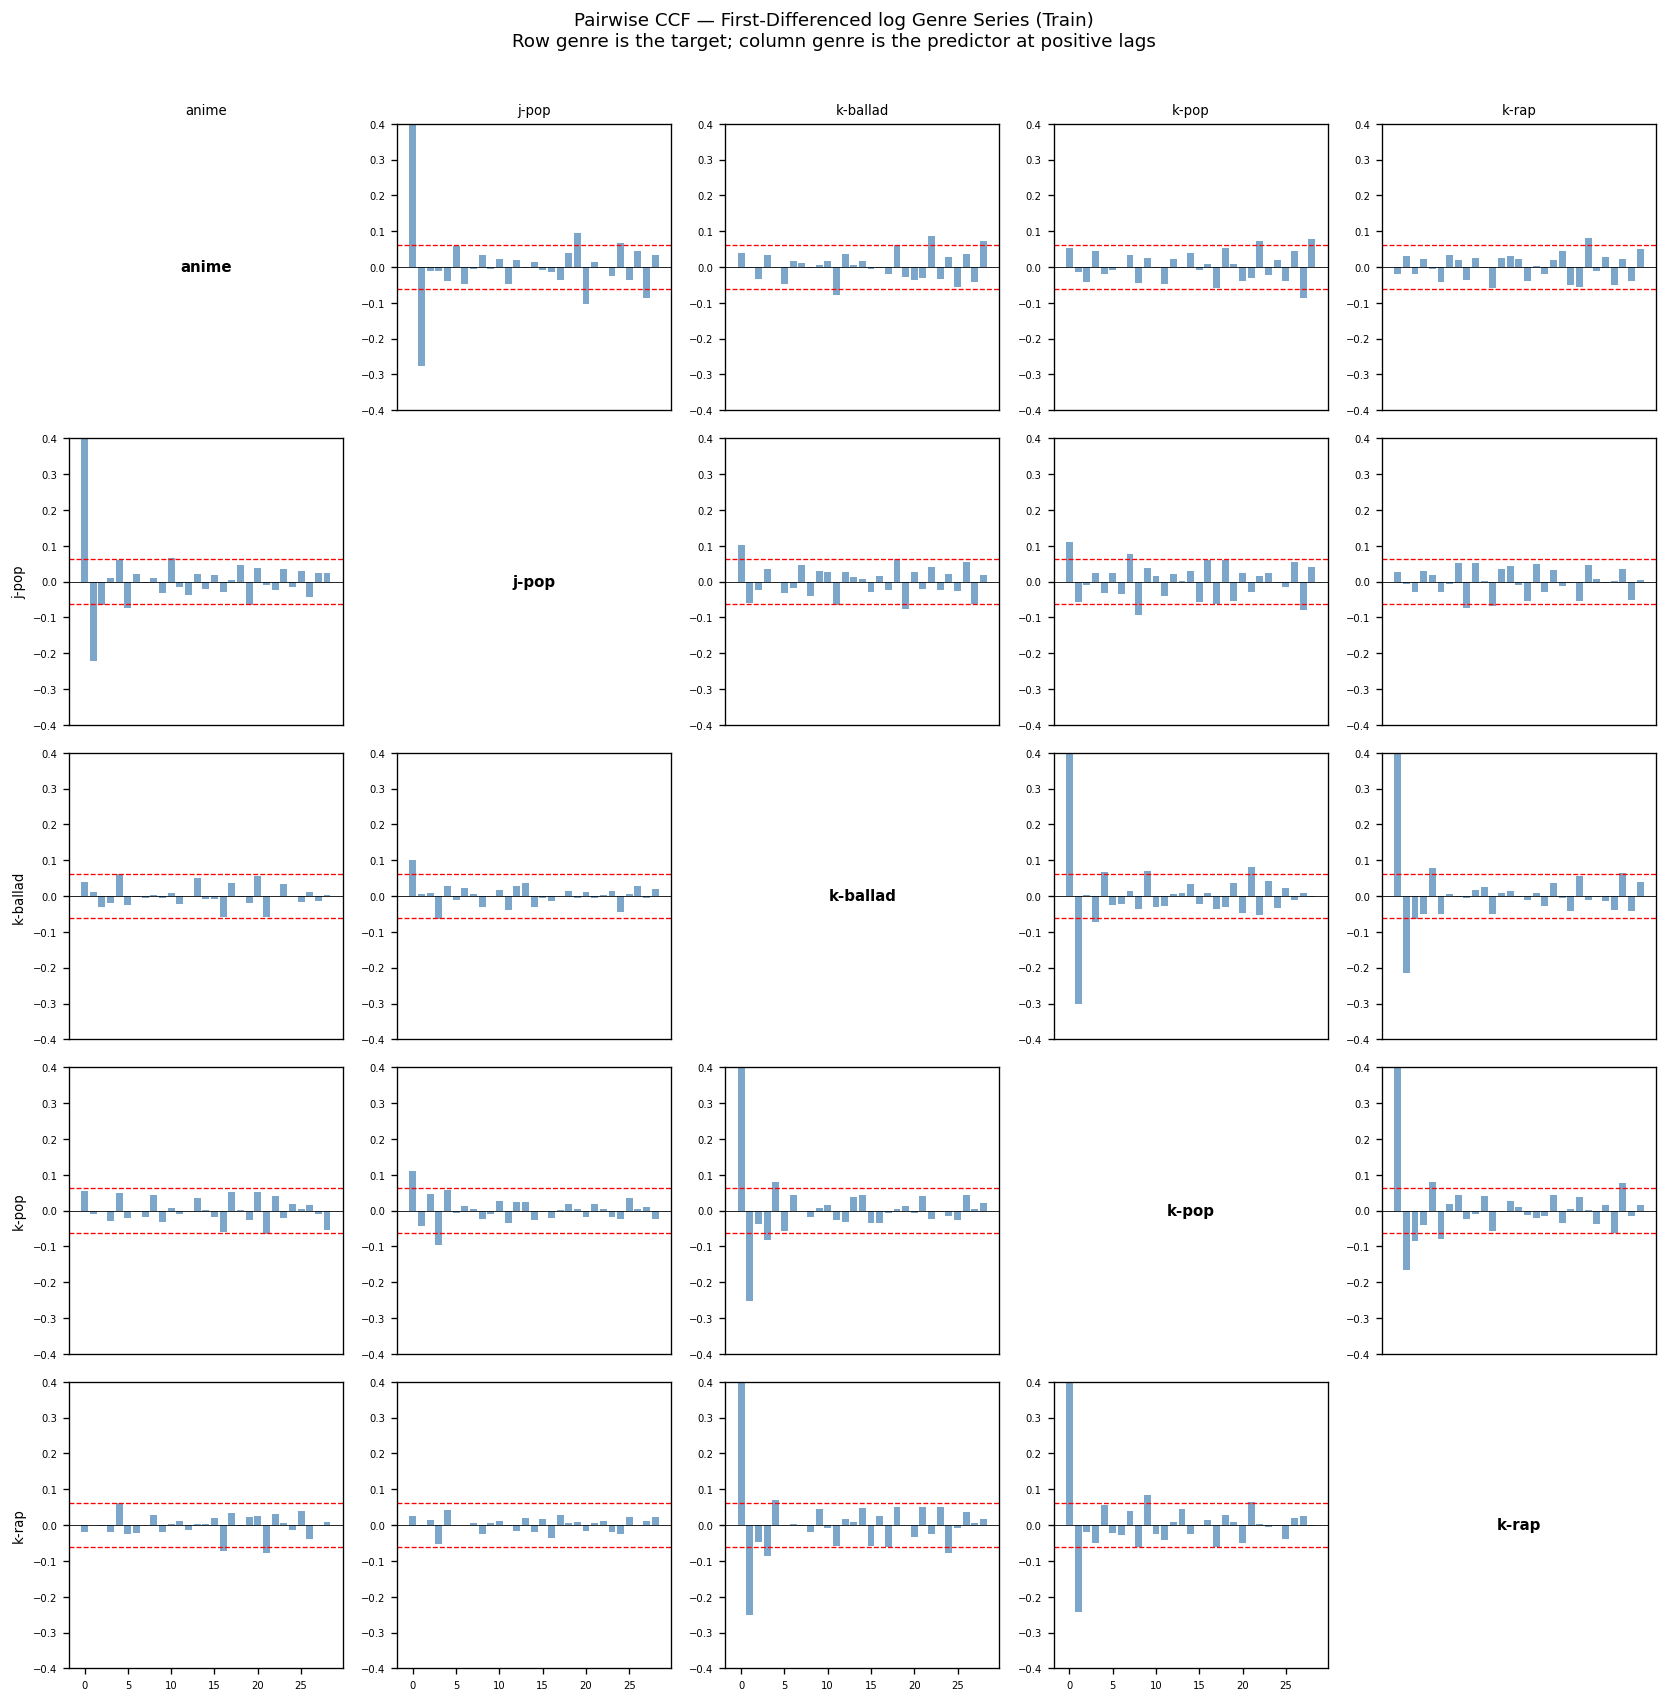

In [21]:
MAX_LAGS = 28  # 4 weeks — enough to capture weekly effects
CI = 1.96 / np.sqrt(len(genre_train_diff))

fig, axes = plt.subplots(n_genres, n_genres, figsize=(14, 14))

for i, g1 in enumerate(genre_names):
    for j, g2 in enumerate(genre_names):
        ax = axes[i, j]
        if i == j:
            # Diagonal: label only
            ax.text(0.5, 0.5, g1, ha="center", va="center",
                    transform=ax.transAxes, fontsize=9, fontweight="bold")
            ax.set_facecolor("blue")
            ax.axis("off")
        else:
            x = genre_train_diff[g1].values
            y = genre_train_diff[g2].values
            # CCF: effect of g2 (column) on g1 (row) at positive lags
            n     = len(x)
            ccf_vals = np.array([
                np.corrcoef(x[lag:], y[:n-lag])[0,1] if lag > 0
                else np.corrcoef(x, y)[0,1]
                for lag in range(MAX_LAGS + 1)
            ])
            lags = np.arange(len(ccf_vals))
            ax.bar(lags, ccf_vals, color="steelblue", width=0.8, alpha=0.7)
            ax.axhline( CI, ls="--", color="red", lw=0.8)
            ax.axhline(-CI, ls="--", color="red", lw=0.8)
            ax.axhline(0,   color="black", lw=0.5)
            ax.set_ylim(-0.4, 0.4)
            ax.tick_params(labelsize=6)

        if i == 0:
            ax.set_title(genre_names[j], fontsize=8)
        if j == 0:
            ax.set_ylabel(genre_names[i], fontsize=8)
        if i < n_genres - 1:
            ax.set_xticks([])

fig.suptitle(
    "Pairwise CCF — First-Differenced log Genre Series (Train)\n"
    "Row genre is the target; column genre is the predictor at positive lags",
    y=1.01, fontsize=11
)
plt.tight_layout()
plt.savefig("../plots/ccf_matrix.png", bbox_inches="tight")
plt.show()

Visually, we can observe which pairs of genres are most highly correlated: `j-pop` and `anime`, `k-ballad` and `kpop`, `k-ballad` and `k-rap`, and `k-pop` and `k-rap`, which is not surprising since these are just clusters within language. The correlation heatmap should show similar results. Of note, it's only a measurement of correlation at a lag of 0 (so same-day listening).

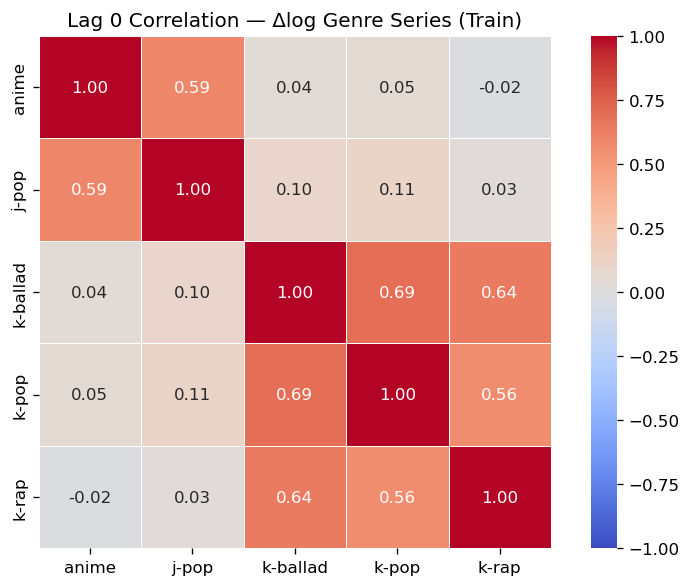

In [22]:
corr_matrix = genre_train_diff.corr()

plt.figure(figsize=(7, 5))
sns.heatmap(
    corr_matrix,
    annot=True, fmt=".2f",
    cmap="coolwarm", center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True
)
plt.title("Lag 0 Correlation — Δlog Genre Series (Train)")
plt.tight_layout()
plt.savefig("../plots/genre_corr_heatmap.png", bbox_inches="tight")
plt.show()

What's interesting is that there seems to be little correlation between these two clusters, which is surprising. I would've thought that `j-pop` and `k-pop` would have a stronger correlation since they're both pop genres. This suggests that I tend to listen to the two languages separately. I have some playlists where the music is separated by language and some where it's not separated (so there may be some `j-pop` songs mixed with `k-pop` songs), but this suggests that I don't listen to the two together very much.

The between-language correlation is interesting, but it could also be an artifact of the fact that Spotify pulls genres at the artist level and an artist can have multiple genres, so listening to a song by that artist will inherently result in high correlation between the two.

Let's now build the VAR model to try to predict on the test set. We'll use AIC as the model selection criteria for which lag to select, but we'll also record the BIC, which tends to favor smaller models.

In [23]:
var_model     = VAR(genre_train_diff)
lag_selection = var_model.select_order(maxlags=14)
print("\nVAR Lag Order Selection:")
print(lag_selection.summary())

# Use AIC-selected lag but record BIC
best_lag_aic = lag_selection.aic
best_lag_bic = lag_selection.bic
print(f"\nAIC selects lag: {best_lag_aic}")
print(f"BIC selects lag: {best_lag_bic}")

# Use AIC selection for fitting
best_lag = best_lag_aic


VAR Lag Order Selection:
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0     -0.07942    -0.05452      0.9237    -0.06995
1       -1.088     -0.9383      0.3370      -1.031
2       -1.452      -1.178      0.2341      -1.348
3       -1.646      -1.248      0.1928      -1.494
4       -1.781     -1.258*      0.1685      -1.582
5       -1.879      -1.231      0.1528     -1.632*
6       -1.908      -1.137      0.1483      -1.615
7       -1.934      -1.038      0.1446      -1.593
8      -1.946*     -0.9253     0.1429*      -1.558
9       -1.942     -0.7967      0.1435      -1.506
10      -1.913     -0.6436      0.1477      -1.430
11      -1.893     -0.4992      0.1506      -1.363
12      -1.887     -0.3685      0.1516      -1.309
13      -1.875     -0.2317      0.1535      -1.250
14      -1.846    -0.07790      0.1581      -1.173
--------------------------------------------------

AIC 

The two differ in their selection, but let's fit the VAR with 8 lags and model residuals. The reason for doing so is that AIC penalizes underfitting less aggressively than BIC. Here, I'm making the call that including a cross-genre lag that isn't real is not as bad as omitting one that is real.

In [24]:
var_fit = var_model.fit(maxlags=best_lag, ic=None)  # fit at selected lag
print(var_fit.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Wed, 13, May, 2026
Time:                     23:03:12
--------------------------------------------------------------------
No. of Equations:         5.00000    BIC:                  -0.938283
Nobs:                     988.000    HQIC:                  -1.56779
Log likelihood:          -5839.24    FPE:                   0.141727
AIC:                     -1.95409    Det(Omega_mle):        0.115654
--------------------------------------------------------------------
Results for equation anime
                 coefficient       std. error           t-stat            prob
------------------------------------------------------------------------------
const               0.005773         0.028592            0.202           0.840
L1.anime           -0.605689         0.040136          -15.091           0.000
L1.j-pop           -0.095605         0.046051           -2.076      

There are many things to look at for the coefficients table, but the key one is that for a given genre, the own-lag coefficients are all large, negative, and highly significant. For example, for anime, L1.anime = -0.606, L2.anime = -0.544, L3.anime = -0.335. This means that a surge in listening to one genre is reliably followed by a pullback over the next several days. That is, I might listen to a genre a lot for one day, but over the next few days, I'll listen to it less and less. Second, note that most cross-genre coefficients are small and statistically insignificant, suggesting that past listening to one genre does not systematically predict future listening to another.


--- Durbin-Watson Statistics ---
anime: DW = 2.004
j-pop: DW = 2.012
k-ballad: DW = 2.003
k-pop: DW = 2.013
k-rap: DW = 2.006

--- Ljung-Box Tests on VAR Residuals ---

anime:
      lb_stat  lb_pvalue
7    2.819225   0.901207
14  18.101517   0.202196

j-pop:
      lb_stat  lb_pvalue
7    4.302447   0.744357
14  13.241754   0.507582

k-ballad:
      lb_stat  lb_pvalue
7    2.270708   0.943352
14  13.918137   0.455828

k-pop:
      lb_stat  lb_pvalue
7    1.934174   0.963394
14  13.356407   0.498672

k-rap:
     lb_stat  lb_pvalue
7    1.95545   0.962265
14  11.82261   0.620546


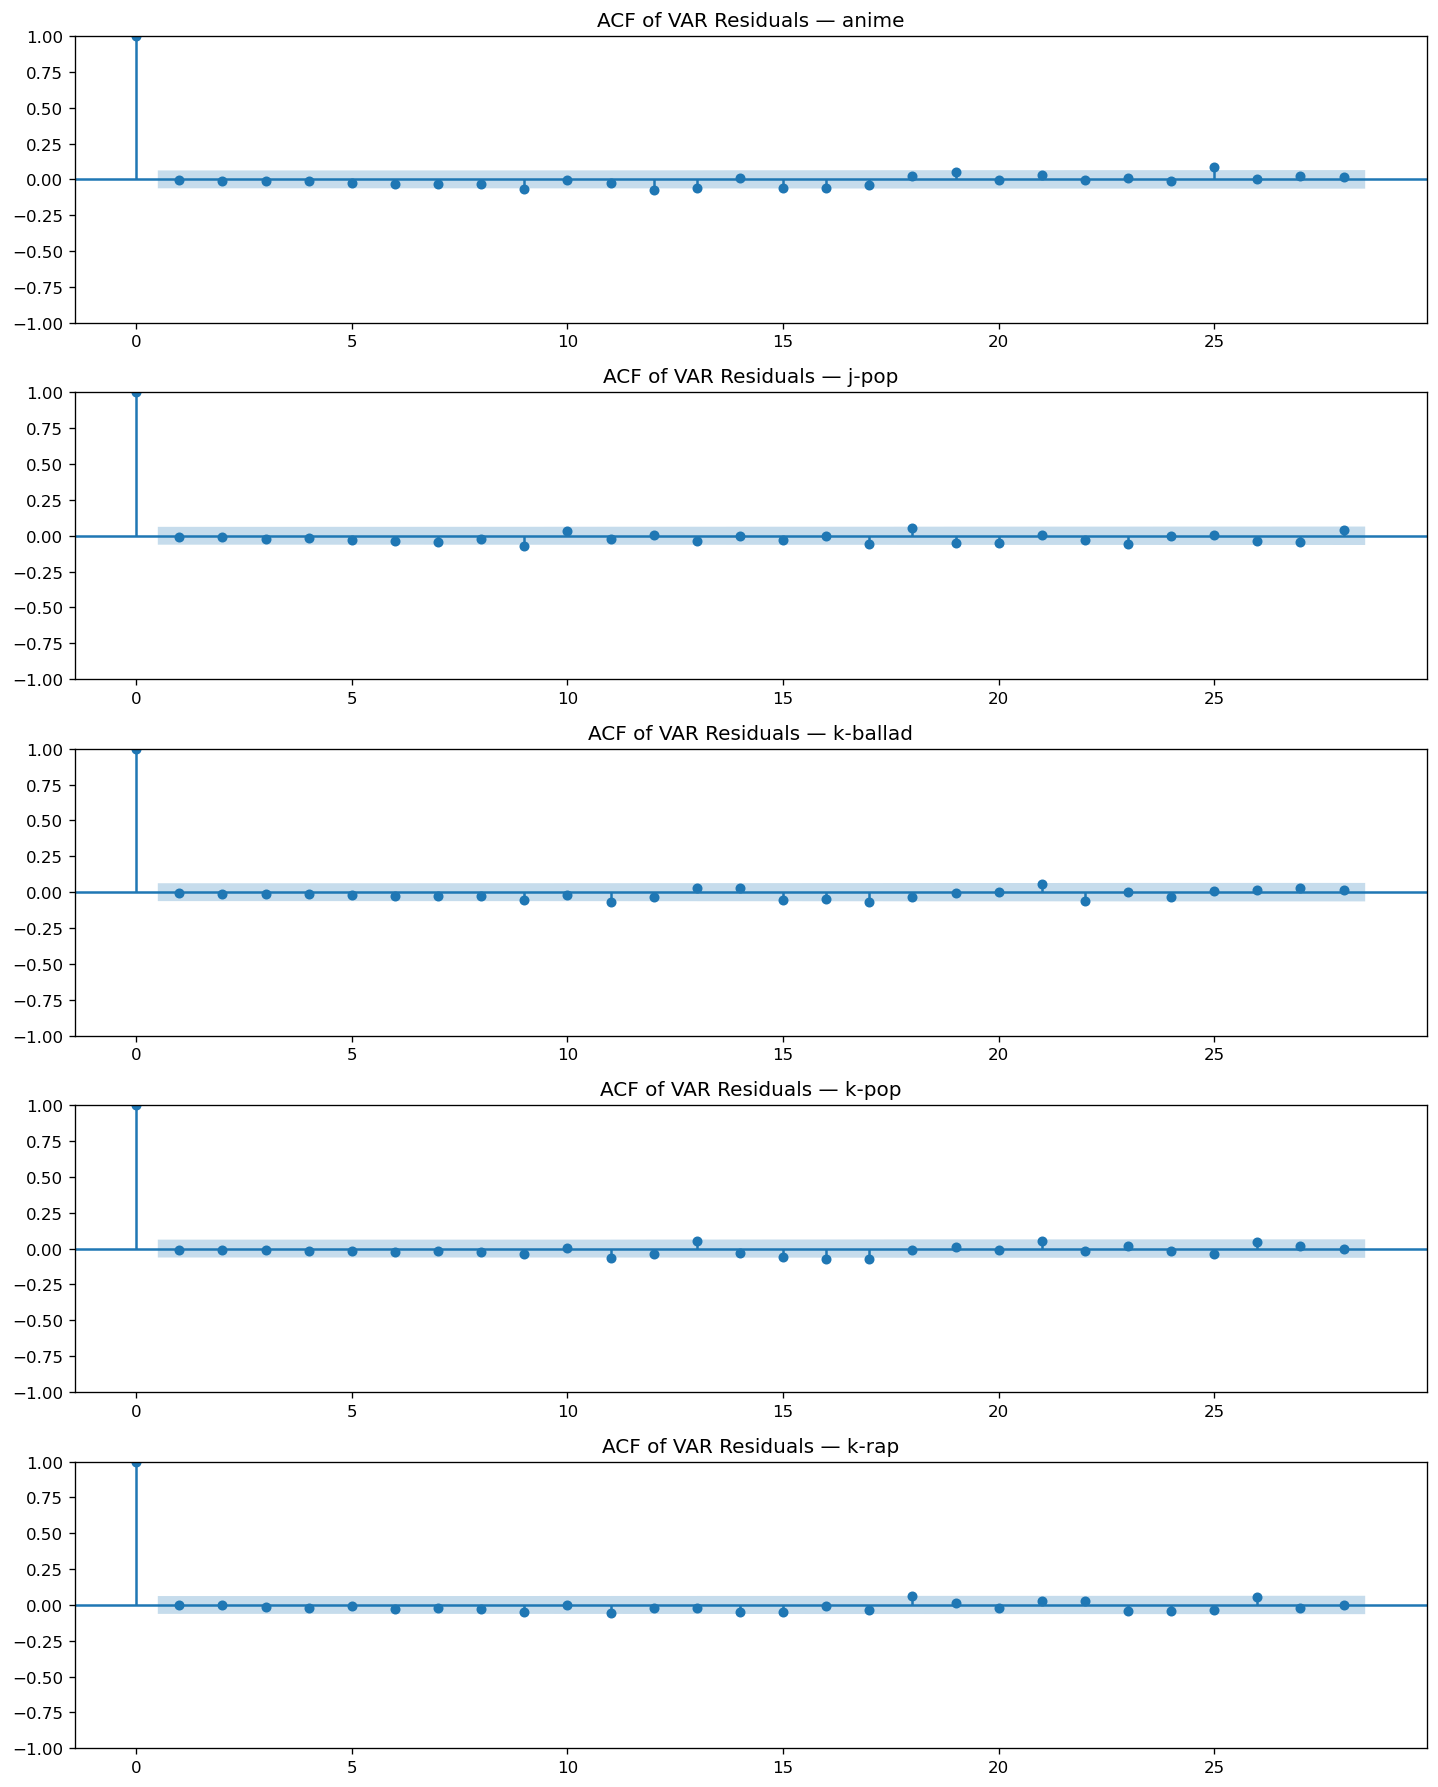

In [25]:
print("\n--- Durbin-Watson Statistics ---")
dw_stats = durbin_watson(var_fit.resid)
for g, dw in zip(genre_names, dw_stats):
    flag = "Warning: (autocorrelation present)" if abs(dw - 2.0) > 0.5 else ""
    print(f"{g}: DW = {dw:.3f}{flag}")

print("\n--- Ljung-Box Tests on VAR Residuals ---")
for g in genre_names:
    lb = acorr_ljungbox(var_fit.resid[g], lags=[7, 14], return_df=True)
    print(f"\n{g}:")
    print(lb.to_string())

# Residual ACF grid
fig, axes = plt.subplots(n_genres, 1, figsize=(12, 3 * n_genres))
for ax, g in zip(axes, genre_names):
    plot_acf(var_fit.resid[g], lags=28, ax=ax, title=f"ACF of VAR Residuals — {g}")
plt.tight_layout()
plt.savefig("../plots/var_residual_acf.png", bbox_inches="tight")
plt.show()

From our residual diagnostic tests and plots, we see that the results are rather clean. The Durbin-Watson statistics are all $\sim$ 2, suggesting practically no autocorrelation in the residuals. We can verify that in the ACF plot, which shows that at lag 1, the model has fully absorbed the autocorrelation structure. As another point of evidence, the Ljung-Box p-value is well-above 0.05 for lags of 7 and 14, suggesting that we didn't miss any seasonality effect. Overall, this exercise shows that we've properly modeled the cross-genre dynamics, but that they're relatively weak.

Let's do Granger cauality tests to see if one series is useful for forecasting another.

In [26]:
BONFERRONI_ALPHA = 0.05 / (n_genres * (n_genres - 1))
print(f"\n--- Granger Causality Tests (Bonferroni-corrected α = {BONFERRONI_ALPHA:.4f}) ---")
print(f"{'Pair':<30} {'Min p-value':>12} {'Significant?':>14}")
print("-" * 60)

granger_results = {}
for g1 in genre_names:
    for g2 in genre_names:
        if g1 == g2:
            continue
        test_data = genre_train_diff[[g1, g2]].dropna()
        try:
            result = grangercausalitytests(test_data, maxlag=best_lag, verbose=False)
            min_p = min(result[lag][0]["ssr_ftest"][1] for lag in result)
            sig = "YES **" if min_p < BONFERRONI_ALPHA else "no"
            granger_results[(g2, g1)] = min_p  # g2 causes g1
            print(f"{g2} --> {g1}:<br>{' ':<26} {min_p:>12.4f} {sig:>14}")
        except Exception as e:
            print(f"{g2}-->{g1}: ERROR ({e})")


--- Granger Causality Tests (Bonferroni-corrected α = 0.0025) ---
Pair                            Min p-value   Significant?
------------------------------------------------------------
j-pop --> anime:<br>                                 0.0746             no
k-ballad --> anime:<br>                                 0.6158             no
k-pop --> anime:<br>                                 0.5111             no
k-rap --> anime:<br>                                 0.4273             no
anime --> j-pop:<br>                                 0.0061             no
k-ballad --> j-pop:<br>                                 0.4318             no
k-pop --> j-pop:<br>                                 0.5122             no
k-rap --> j-pop:<br>                                 0.5636             no
anime --> k-ballad:<br>                                 0.3531             no
j-pop --> k-ballad:<br>                                 0.0305             no
k-pop --> k-ballad:<br>                            

After applying Bonferonni correction, the only pair of genres where we observe one being useful in predicting the other is `k-rap` --> `k-pop`. This means that past `k-rap` listening provides statistically significant predictive power for future `k-pop` listening, beyond what `k-pop`'s own history explains, likely due to them sharing many characteristics. However, this relationship is asymmetric. `k-pop` doesn't seem to provide any significant predictive power for future `k-rap` listening, which means that `k-rap` may serve as a gateway to listening to `k-pop`, but not the other way around.

Let's perform prediction on a test set and see how it compares to a baseline prediction of predicting the mean.


--- VAR Test Set Evaluation (first-differenced log scale) ---
-----------------------------------------------------------------
Mean Baseline --> anime             RMSE =   1.41 MAE =   1.08
VAR --> anime                       RMSE =   1.41 MAE =   1.08

Mean Baseline --> j-pop             RMSE =   1.13 MAE =   0.82
VAR --> j-pop                       RMSE =   1.13 MAE =   0.82

Mean Baseline --> k-ballad          RMSE =   0.94 MAE =   0.63
VAR --> k-ballad                    RMSE =   0.94 MAE =   0.63

Mean Baseline --> k-pop             RMSE =   1.31 MAE =   0.90
VAR --> k-pop                       RMSE =   1.31 MAE =   0.90

Mean Baseline --> k-rap             RMSE =   0.91 MAE =   0.54
VAR --> k-rap                       RMSE =   0.91 MAE =   0.54



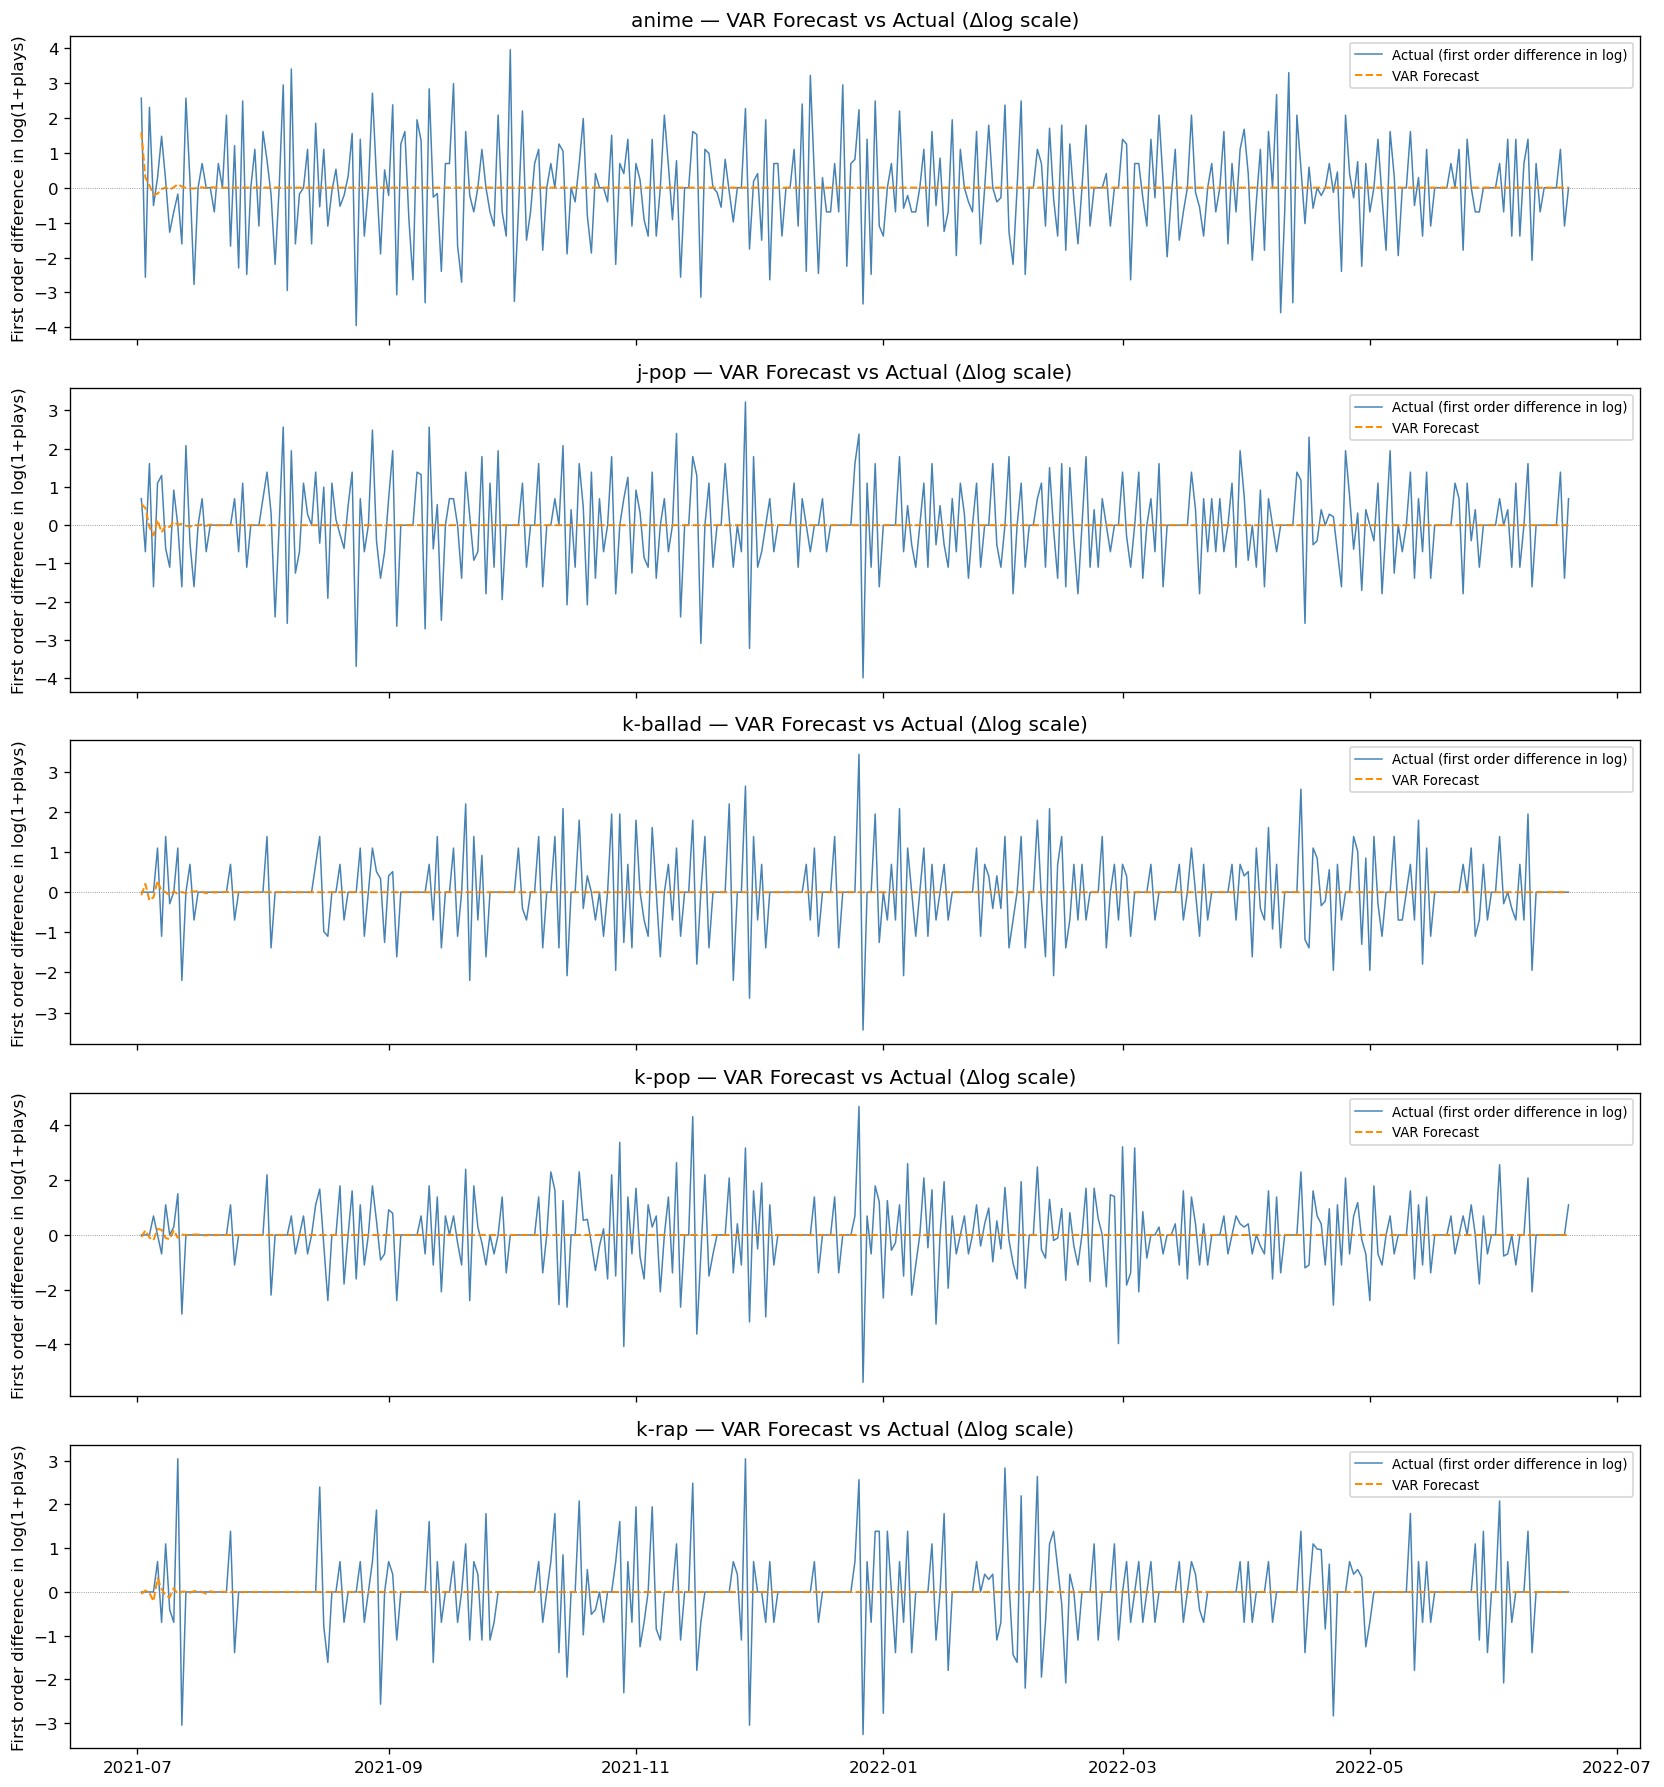

In [27]:
forecast_input = genre_train_diff.values[-best_lag:]
steps = len(genre_test_diff)
var_forecast = var_fit.forecast(y=forecast_input, steps=steps)

var_forecast_df = pd.DataFrame(
    var_forecast,
    index=genre_test_diff.index,
    columns=genre_names
)

# Evaluate: compare against naive mean baseline for each genre
print("\n--- VAR Test Set Evaluation (first-differenced log scale) ---")
print("-" * 65)
for g in genre_names:
    mean_base = np.zeros(steps)  # mean of first-diff ≈ 0 (stationary)
    evaluate(f"Mean Baseline --> {g}", genre_test_diff[g].values, mean_base)
    evaluate(f"VAR --> {g}", genre_test_diff[g].values, var_forecast_df[g].values)
    print()

# Plot VAR forecasts per genre
fig, axes = plt.subplots(n_genres, 1, figsize=(14, 3 * n_genres), sharex=True)
for ax, g in zip(axes, genre_names):
    ax.plot(genre_test_diff.index, genre_test_diff[g],
            label="Actual (first order difference in log)",  lw=0.9, color="steelblue")
    ax.plot(var_forecast_df.index, var_forecast_df[g],
            label="VAR Forecast",   lw=1.2, ls="--", color="darkorange")
    ax.axhline(0, color="grey", lw=0.5, ls=":")
    ax.set_title(f"{g} — VAR Forecast vs Actual (Δlog scale)")
    ax.set_ylabel("First order difference in log(1+plays)")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("../plots/var_forecast.png", bbox_inches="tight")
plt.show()

These VAR models don't perform differently than the mean for all five genres. Similar to the SARIMA models, they try to predict some signal at the start, but that signal quickly converges to predicting the mean across the rest of the span of the testing set. Overall, this project has shown that predicting this far into the future is incredibly difficult for time series analysis.

Despite the predictive performance, the VAR analysis (Granger causality and coefficient resutls) still show intersting results within the training data: that is, the relationship between genres is stratified by language, that a spike in listening to a genre on a given day is followed by a gradual decay, and that there is some predictive power in using `k-rap` to predict `k-pop` listening, but that over time the mean prediction dominates. Regarding the spike/decay pattern, an interpretable result is that we can predict a decay in listening trends after identifying a spike in listening to a certain genre, but it's hard to predict when the spikes occur.

## Results

As a reminder, our research questions were: 

1. Do my listening trends during my undergraduate years exhibit periodicity within either a daily, weekly, or yearly cycle? Can this be used to perform prediction on my listening?
2. Is there are any relationship between my listening trends across my top 5 genres?

And here are the answers:

1. Overall, our results show that it's incredibly difficult to predict listening trends. We observed an upward trend observed during the pandemic period, but after the pandemic, the trend came back down. I was not able to show that my listening trends exhibited any periodicity, as the significant frequencies that were identified ended up just being noise. Additionally, our sinusoidal regression/SARIMA models ended up being no better than the mean when it came to prediction. Due to the lack of seasonality, any spikes in listening can be attributed to random noise and would require either more data or some other type of analysis.

2. There was some relationship between my top 5 genres: we observed that we can cluster the top 5 genres by language, but that relationship was likely due to the way that the data was pulled. From our Granger-causality tests, we observed one relationship being significant: `k-rap` for predicting `k-pop` and that interestingly, this relationship was asymmetric, suggesting some predictive power in predicting `k-pop`, but not that other way around. Overall, we still observed that in the long-run, prediction was still incredibly difficult.